# **Dask on Strato — Setup Guide**

**This guide picks up where the [CLAAUDIA getting-started guide](https://hpc.aau.dk/strato/getting-started/) leaves off. By the end of that guide you have a running Ubuntu VM and can SSH into it. This guide takes you from there to a working multi-VM Dask cluster.**

****VPN required if off-campus.** Strato is only reachable from the AAU network. On campus (group room WiFi or wired) you can reach Strato directly — no VPN needed. Working from home or elsewhere: connect via the AAU VPN first.**

## **Part 1 — Configure the Head Node**

### **1.1 Open the extra ports in your security group**


**Dask needs two ports in addition to SSH:**

1. **In the Strato dashboard, go to **Network → Security Groups.****
2. **Click **Manage Rules** next to your security group.**
3. **Add two rules — click **Add Rule** for each:**

| **Direction** | **Protocol** | **Port** | **Remote**    |
| ------------- | ------------ | -------- | ------------- |
| Ingress       | TCP          | 8787     | 0.0.0.0/0     |
| Ingress       | TCP          | 8786     | 0.0.0.0/0     |

**Port 8786 is the Dask scheduler; port 8787 is the dashboard.**

****Recommended flavor:** `AAU.CPU.b.2-4` (2 vCPUs, 4 GB RAM) for both head node and worker VMs. The CLAAUDIA getting-started guide uses `AAU.CPU.a.1-4` (1 vCPU) — resize before continuing.**

![Screenshot From 2026-03-26 14-24-35.png](<attachment:Screenshot From 2026-03-26 14-24-35.png>)
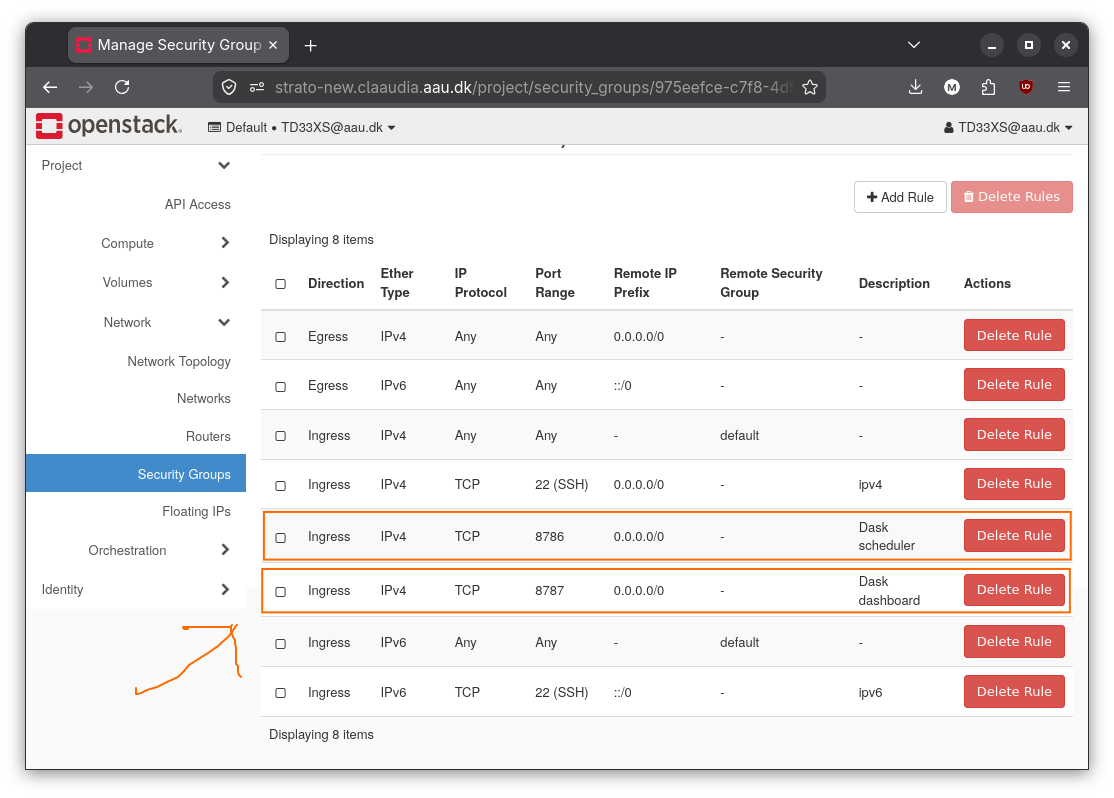

### **1.2 Resize the VM to AAU.CPU.b.2-4**

**The CLAAUDIA getting-started guide launches a `AAU.CPU.a.1-4` VM (1 vCPU). Resize it before proceeding — the head node runs both the Dask scheduler and your Python script, and 1 vCPU causes contention.**

1. ****Shut off the VM first:** in the Strato dashboard go to **Compute → Instances**, click the dropdown → **Shut Off Instance.** Wait until status is Shutoff.**
2. **Click the dropdown again → **Resize Instance**.**
3. **Select `AAU.CPU.b.2-4` (2 vCPUs, 4 GB RAM) and click Resize.**
4. **Once the status changes to **Verify Resize**, click the dropdown → **Confirm Resize**.**
5. **Start the VM again: dropdown → **Start Instance**. Wait until **Active**.**

I created the VM using `AAU.CPU.b.2-4` instead of resizing it.

![Screenshot From 2026-03-26 15-14-59.png](<attachment:Screenshot From 2026-03-26 15-14-59.png>)
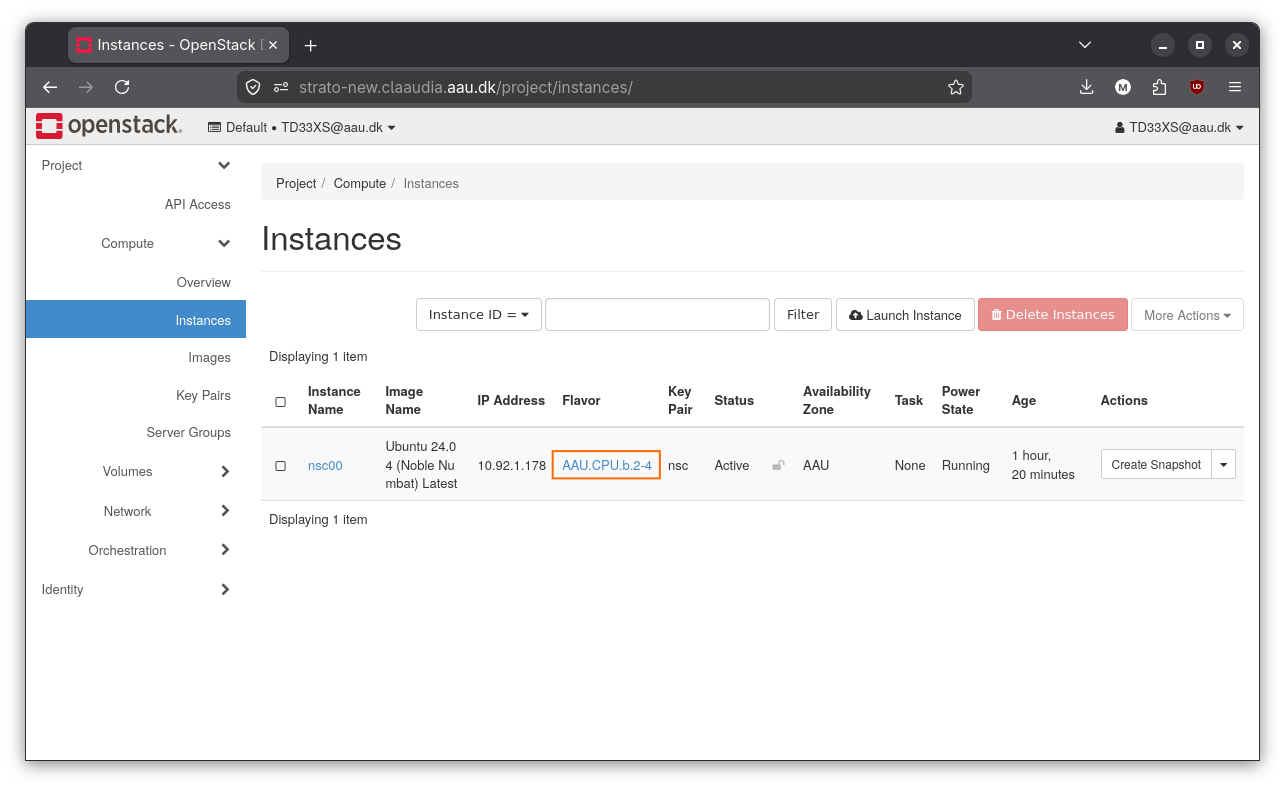

### **1.3 SSH into your VM**

**Use the IP shown in **Compute → Instances** next to your VM (e.g. `10.92.y.x`):**

```sh
ssh -i ~/.ssh/my_ssh_key ubuntu@10.92.y.x
```

**All commands from here until Part 3 are run **on the VM**, not on your laptop.**

I get the following output:

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ ssh -i nsc ubuntu@10.92.1.178
The authenticity of host '10.92.1.178 (10.92.1.178)' can't be established.
ED25519 key fingerprint is: SHA256:/rPURLMrP70tgh0KRq/g/CPCOTd6PZr8uD3UXueOlOM
This key is not known by any other names.
Are you sure you want to continue connecting (yes/no/[fingerprint])? yes
Warning: Permanently added '10.92.1.178' (ED25519) to the list of known hosts.
Welcome to Ubuntu 24.04.4 LTS (GNU/Linux 6.8.0-101-generic x86_64)

 * Documentation:  https://help.ubuntu.com
 * Management:     https://landscape.canonical.com
 * Support:        https://ubuntu.com/pro

 System information as of Thu Mar 26 12:57:49 UTC 2026

  System load:  0.11              Processes:             118
  Usage of /:   3.4% of 47.39GB   Users logged in:       0
  Memory usage: 5%                IPv4 address for ens3: 10.92.1.178
  Swap usage:   0%

Expanded Security Maintenance for Applications is not enabled.

0 updates can be applied immediately.

Enable ESM Apps to receive additional future security updates.
See https://ubuntu.com/esm or run: sudo pro status


The list of available updates is more than a week old.
To check for new updates run: sudo apt update


The programs included with the Ubuntu system are free software;
the exact distribution terms for each program are described in the
individual files in /usr/share/doc/*/copyright.

Ubuntu comes with ABSOLUTELY NO WARRANTY, to the extent permitted by
applicable law.

To run a command as administrator (user "root"), use "sudo <command>".
See "man sudo_root" for details.

ubuntu@nsc00:~$ 
```

### **1.4 Install Miniconda**
```sh
wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
bash Miniconda3-latest-Linux-x86_64.sh -b -p ~/miniconda3
~/miniconda3/bin/conda init bash
source ~/.bashrc
```

I get the following output:

```sh
ubuntu@nsc00:~$ wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
--2026-03-26 12:59:56--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.32.241, 104.16.191.158, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.32.241|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 162067098 (155M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-Linux-x86_64.sh               100%[=====================================================================================================>] 154.56M   140MB/s    in 1.1s    

2026-03-26 12:59:57 (140 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [162067098/162067098]

ubuntu@nsc00:~$ bash Miniconda3-latest-Linux-x86_64.sh -b -p ~/miniconda3
PREFIX=/home/ubuntu/miniconda3
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
ubuntu@nsc00:~$ ~/miniconda3/bin/conda init bash
no change     /home/ubuntu/miniconda3/condabin/conda
no change     /home/ubuntu/miniconda3/bin/conda
no change     /home/ubuntu/miniconda3/bin/conda-env
no change     /home/ubuntu/miniconda3/bin/activate
no change     /home/ubuntu/miniconda3/bin/deactivate
no change     /home/ubuntu/miniconda3/etc/profile.d/conda.sh
no change     /home/ubuntu/miniconda3/etc/fish/conf.d/conda.fish
no change     /home/ubuntu/miniconda3/shell/condabin/Conda.psm1
no change     /home/ubuntu/miniconda3/shell/condabin/conda-hook.ps1
no change     /home/ubuntu/miniconda3/lib/python3.13/site-packages/xontrib/conda.xsh
no change     /home/ubuntu/miniconda3/etc/profile.d/conda.csh
modified      /home/ubuntu/.bashrc

==> For changes to take effect, close and re-open your current shell. <==

ubuntu@nsc00:~$ source ~/.bashrc
(base) ubuntu@nsc00:~$
```

**Verify it worked:**
```sh
conda --version
```

I get the following output:

```sh
(base) ubuntu@nsc00:~$ conda --version
conda 26.1.1
```

### **1.5 Create the Python environment**
```sh
conda create -n nsc python=3.11 "dask[distributed]" numba numpy matplotlib -c conda-forge -y
conda activate nsc
```
**If you see a CondaToSNonInteractiveError about Terms of Service, run these two lines exactly as shown, then re-run the conda create command above:**
```sh
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
```
**This takes a couple of minutes. When it finishes, verify the key packages. Make sure your prompt shows `(nsc)` before running — if it still shows `(base)`, `run conda activate nsc` first:**
```sh
python -c "import dask, numba, numpy; print(dask.__version__, numba.__version__, numpy.__version__)"
```

I get the following output:

```sh
(base) ubuntu@nsc00:~$ conda create -n nsc python=3.11 "dask[distributed]" numba numpy matplotlib -c conda-forge -y

CondaToSNonInteractiveError: Terms of Service have not been accepted for the following channels. Please accept or remove them before proceeding:
    - https://repo.anaconda.com/pkgs/main
    - https://repo.anaconda.com/pkgs/r

To accept these channels' Terms of Service, run the following commands:
    conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

For information on safely removing channels from your conda configuration,
please see the official documentation:

    https://www.anaconda.com/docs/tools/working-with-conda/channels

```

```sh
(base) ubuntu@nsc00:~$ conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
(base) ubuntu@nsc00:~$ conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
```

Then I can install and activate:

```sh
(base) ubuntu@ncs00:~$ conda create -n nsc python=3.11 "dask[distributed]" numba numpy matplotlib -c conda-forge -y
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Collecting package metadata (repodata.json): done
Solving environment: done

## Package Plan ##

  environment location: /home/ubuntu/miniconda3/envs/nsc

  added / updated specs:
    - dask
    - matplotlib
    - numba
    - numpy
    - python=3.11


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    alsa-lib-1.2.15.3          |       hb03c661_0         571 KB  conda-forge
    aws-c-auth-0.10.1          |       h2d2dd48_2         131 KB  conda-forge
    aws-c-cal-0.9.13           |       h2c9d079_1          55 KB  conda-forge
    aws-c-common-0.12.6        |       hb03c661_0         234 KB  conda-forge
    aws-c-compression-0.3.2    |       h8b1a151_0          22 KB  conda-forge
    aws-c-event-stream-0.6.0   |       h9b893ba_1          58 KB  conda-forge
    aws-c-http-0.10.12         |       h4bacb7b_1         221 KB  conda-forge
    aws-c-io-0.26.3            |       hc87160b_0         177 KB  conda-forge
    aws-c-mqtt-0.15.2          |       he9ea9c5_1         217 KB  conda-forge
    aws-c-s3-0.11.5            |       h6d69fc9_5         148 KB  conda-forge
    aws-c-sdkutils-0.2.4       |       h8b1a151_4          58 KB  conda-forge
    aws-checksums-0.2.10       |       h8b1a151_0          99 KB  conda-forge
    aws-crt-cpp-0.37.4         |       h4c8aef7_3         401 KB  conda-forge
    aws-sdk-cpp-1.11.747       |       hc3785e1_3         3.5 MB  conda-forge
    azure-core-cpp-1.16.2      |       h206d751_0         341 KB  conda-forge
    azure-identity-cpp-1.13.3  |       hed0cdb0_1         245 KB  conda-forge
    azure-storage-blobs-cpp-12.16.0|       hdd73cc9_1         566 KB  conda-forge
    azure-storage-common-cpp-12.12.0|       ha7a2c86_1         147 KB  conda-forge
    azure-storage-files-datalake-cpp-12.14.0|       h52c5a47_1         295 KB  conda-forge
    backports.zstd-1.3.0       |  py311h6b1f9c4_0         239 KB  conda-forge
    bokeh-3.9.0                |     pyhd8ed1ab_0         4.0 MB  conda-forge
    brotli-1.2.0               |       hed03a55_1          20 KB  conda-forge
    brotli-bin-1.2.0           |       hb03c661_1          21 KB  conda-forge
    brotli-python-1.2.0        |  py311h66f275b_1         359 KB  conda-forge
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    cairo-1.18.4               |       he90730b_1         966 KB  conda-forge
    click-8.3.1                |     pyh8f84b5b_1          95 KB  conda-forge
    cloudpickle-3.1.2          |     pyhcf101f3_1          27 KB  conda-forge
    contourpy-1.3.3            |  py311h724c32c_4         313 KB  conda-forge
    cycler-0.12.1              |     pyhcf101f3_2          14 KB  conda-forge
    cyrus-sasl-2.1.28          |       hac629b4_1         205 KB  conda-forge
    cytoolz-1.1.0              |  py311h49ec1c0_2         609 KB  conda-forge
    dask-2026.3.0              |     pyhc364b38_0          11 KB  conda-forge
    dask-core-2026.3.0         |     pyhc364b38_0         1.0 MB  conda-forge
    dbus-1.16.2                |       h24cb091_1         437 KB  conda-forge
    distributed-2026.3.0       |     pyhc364b38_0         826 KB  conda-forge
    double-conversion-3.4.0    |       hecca717_0          70 KB  conda-forge
    font-ttf-dejavu-sans-mono-2.37|       hab24e00_0         388 KB  conda-forge
    font-ttf-inconsolata-3.000 |       h77eed37_0          94 KB  conda-forge
    font-ttf-source-code-pro-2.038|       h77eed37_0         684 KB  conda-forge
    font-ttf-ubuntu-0.83       |       h77eed37_3         1.5 MB  conda-forge
    fontconfig-2.17.1          |       h27c8c51_0         264 KB  conda-forge
    fonts-conda-ecosystem-1    |                0           4 KB  conda-forge
    fonts-conda-forge-1        |       hc364b38_1           4 KB  conda-forge
    fonttools-4.62.0           |  py311h3778330_0         2.9 MB  conda-forge
    freetype-2.14.3            |       ha770c72_0         170 KB  conda-forge
    fsspec-2026.2.0            |     pyhd8ed1ab_0         145 KB  conda-forge
    gflags-2.2.2               |    h5888daf_1005         117 KB  conda-forge
    glog-0.7.1                 |       hbabe93e_0         140 KB  conda-forge
    graphite2-1.3.14           |       hecca717_2          97 KB  conda-forge
    h2-4.3.0                   |     pyhcf101f3_0          94 KB  conda-forge
    harfbuzz-13.2.1            |       h6083320_0         2.3 MB  conda-forge
    hpack-4.1.0                |     pyhd8ed1ab_0          30 KB  conda-forge
    hyperframe-6.1.0           |     pyhd8ed1ab_0          17 KB  conda-forge
    icu-78.3                   |       h33c6efd_0        12.1 MB  conda-forge
    importlib-metadata-8.8.0   |     pyhcf101f3_0          34 KB  conda-forge
    jinja2-3.1.6               |     pyhcf101f3_1         118 KB  conda-forge
    keyutils-1.6.3             |       hb9d3cd8_0         131 KB  conda-forge
    kiwisolver-1.5.0           |  py311h724c32c_0          76 KB  conda-forge
    krb5-1.22.2                |       ha1258a1_0         1.3 MB  conda-forge
    lcms2-2.18                 |       h0c24ade_0         244 KB  conda-forge
    ld_impl_linux-64-2.45.1    |default_hbd61a6d_102         711 KB  conda-forge
    lerc-4.1.0                 |       hdb68285_0         255 KB  conda-forge
    libabseil-20260107.1       | cxx17_h7b12aa8_0         1.3 MB  conda-forge
    libarrow-23.0.1            |   ha7f89c6_9_cpu         6.2 MB  conda-forge
    libarrow-acero-23.0.1      |   h635bf11_9_cpu         595 KB  conda-forge
    libarrow-compute-23.0.1    |   h53684a4_9_cpu         2.9 MB  conda-forge
    libarrow-dataset-23.0.1    |   h635bf11_9_cpu         593 KB  conda-forge
    libarrow-substrait-23.0.1  |   hb4dd7c2_9_cpu         507 KB  conda-forge
    libblas-3.11.0             |6_h4a7cf45_openblas          18 KB  conda-forge
    libbrotlicommon-1.2.0      |       hb03c661_1          78 KB  conda-forge
    libbrotlidec-1.2.0         |       hb03c661_1          34 KB  conda-forge
    libbrotlienc-1.2.0         |       hb03c661_1         291 KB  conda-forge
    libcblas-3.11.0            |6_h0358290_openblas          18 KB  conda-forge
    libclang-cpp22.1-22.1.0    |default_h99862b1_0        20.7 MB  conda-forge
    libclang13-22.1.0          |default_h746c552_0        12.2 MB  conda-forge
    libcrc32c-1.1.2            |       h9c3ff4c_0          20 KB  conda-forge
    libcups-2.3.3              |       h7a8fb5f_6         4.3 MB  conda-forge
    libcurl-8.19.0             |       hcf29cc6_0         456 KB  conda-forge
    libdeflate-1.25            |       h17f619e_0          72 KB  conda-forge
    libdrm-2.4.125             |       hb03c661_1         304 KB  conda-forge
    libedit-3.1.20250104       | pl5321h7949ede_0         132 KB  conda-forge
    libegl-1.7.0               |       ha4b6fd6_2          44 KB  conda-forge
    libev-4.33                 |       hd590300_2         110 KB  conda-forge
    libevent-2.1.12            |       hf998b51_1         417 KB  conda-forge
    libexpat-2.7.4             |       hecca717_0          75 KB  conda-forge
    libffi-3.5.2               |       h3435931_0          57 KB  conda-forge
    libfreetype-2.14.3         |       ha770c72_0           8 KB  conda-forge
    libfreetype6-2.14.3        |       h73754d4_0         376 KB  conda-forge
    libgcc-15.2.0              |      he0feb66_18        1017 KB  conda-forge
    libgcc-ng-15.2.0           |      h69a702a_18          27 KB  conda-forge
    libgfortran-15.2.0         |      h69a702a_18          27 KB  conda-forge
    libgfortran5-15.2.0        |      h68bc16d_18         2.4 MB  conda-forge
    libgl-1.7.0                |       ha4b6fd6_2         132 KB  conda-forge
    libglib-2.86.4             |       h6548e54_1         4.2 MB  conda-forge
    libglvnd-1.7.0             |       ha4b6fd6_2         129 KB  conda-forge
    libglx-1.7.0               |       ha4b6fd6_2          74 KB  conda-forge
    libgomp-15.2.0             |      he0feb66_18         589 KB  conda-forge
    libgoogle-cloud-3.3.0      |       h25dbb67_1         2.4 MB  conda-forge
    libgoogle-cloud-storage-3.3.0|       hdbdcf42_1         761 KB  conda-forge
    libgrpc-1.78.1             |       h1d1128b_0         6.7 MB  conda-forge
    libiconv-1.18              |       h3b78370_2         772 KB  conda-forge
    libjpeg-turbo-3.1.2        |       hb03c661_0         619 KB  conda-forge
    liblapack-3.11.0           |6_h47877c9_openblas          18 KB  conda-forge
    libllvm22-22.1.2           |       hf7376ad_0        42.2 MB  conda-forge
    liblzma-5.8.2              |       hb03c661_0         111 KB  conda-forge
    libnghttp2-1.68.1          |       h877daf1_0         648 KB  conda-forge
    libnsl-2.0.1               |       hb9d3cd8_1          33 KB  conda-forge
    libntlm-1.8                |       hb9d3cd8_0          33 KB  conda-forge
    libopenblas-0.3.32         |pthreads_h94d23a6_0         5.7 MB  conda-forge
    libopengl-1.7.0            |       ha4b6fd6_2          50 KB  conda-forge
    libopentelemetry-cpp-1.26.0|       h9692893_0         912 KB  conda-forge
    libopentelemetry-cpp-headers-1.26.0|       ha770c72_0         387 KB  conda-forge
    libparquet-23.0.1          |   h7376487_9_cpu         1.3 MB  conda-forge
    libpciaccess-0.18          |       hb9d3cd8_0          28 KB  conda-forge
    libpng-1.6.56              |       h421ea60_0         310 KB  conda-forge
    libpq-18.3                 |       h9abb657_0         2.7 MB  conda-forge
    libprotobuf-6.33.5         |       h2b00c02_0         3.5 MB  conda-forge
    libre2-11-2025.11.05       |       h0dc7533_1         208 KB  conda-forge
    libsqlite-3.52.0           |       hf4e2dac_0         929 KB  conda-forge
    libssh2-1.11.1             |       hcf80075_0         298 KB  conda-forge
    libstdcxx-15.2.0           |      h934c35e_18         5.6 MB  conda-forge
    libstdcxx-ng-15.2.0        |      hdf11a46_18          27 KB  conda-forge
    libthrift-0.22.0           |       h454ac66_1         414 KB  conda-forge
    libtiff-4.7.1              |       h9d88235_1         425 KB  conda-forge
    libutf8proc-2.11.3         |       hfe17d71_0          84 KB  conda-forge
    libuuid-2.41.3             |       h5347b49_0          39 KB  conda-forge
    libvulkan-loader-1.4.341.0 |       h5279c79_0         195 KB  conda-forge
    libwebp-base-1.6.0         |       hd42ef1d_0         419 KB  conda-forge
    libxcb-1.17.0              |       h8a09558_0         387 KB  conda-forge
    libxcrypt-4.4.36           |       hd590300_1          98 KB  conda-forge
    libxkbcommon-1.13.1        |       hca5e8e5_0         818 KB  conda-forge
    libxml2-2.15.2             |       he237659_0          45 KB  conda-forge
    libxml2-16-2.15.2          |       hca6bf5a_0         544 KB  conda-forge
    libxslt-1.1.43             |       h711ed8c_1         240 KB  conda-forge
    libzlib-1.3.2              |       h25fd6f3_2          62 KB  conda-forge
    llvmlite-0.46.0            |  py311h41a00d4_0        32.5 MB  conda-forge
    locket-1.0.0               |     pyhd8ed1ab_0           8 KB  conda-forge
    lz4-4.4.5                  |  py311h1c460e0_1          43 KB  conda-forge
    lz4-c-1.10.0               |       h5888daf_1         163 KB  conda-forge
    markupsafe-3.0.3           |  py311h3778330_1          26 KB  conda-forge
    matplotlib-3.10.8          |  py311h38be061_0          17 KB  conda-forge
    matplotlib-base-3.10.8     |  py311h0f3be63_0         7.9 MB  conda-forge
    msgpack-python-1.1.2       |  py311hdf67eae_1         101 KB  conda-forge
    munkres-1.1.4              |     pyhd8ed1ab_1          15 KB  conda-forge
    narwhals-2.18.1            |     pyhcf101f3_1         274 KB  conda-forge
    ncurses-6.5                |       h2d0b736_3         871 KB  conda-forge
    nlohmann_json-3.12.0       |       h54a6638_1         133 KB  conda-forge
    numba-0.64.0               |  py311h3c884d5_0         5.6 MB  conda-forge
    numpy-2.4.3                |  py311h2e04523_0         8.9 MB  conda-forge
    openjpeg-2.5.4             |       h55fea9a_0         347 KB  conda-forge
    openldap-2.6.10            |       hbde042b_1         767 KB  conda-forge
    openssl-3.6.1              |       h35e630c_1         3.0 MB  conda-forge
    orc-2.3.0                  |       h21090e2_0         1.4 MB  conda-forge
    packaging-26.0             |     pyhcf101f3_0          70 KB  conda-forge
    pandas-3.0.1               |  py311h8032f78_0        14.4 MB  conda-forge
    partd-1.4.2                |     pyhd8ed1ab_0          20 KB  conda-forge
    pcre2-10.47                |       haa7fec5_0         1.2 MB  conda-forge
    pillow-12.1.1              |  py311hf88fc01_0        1022 KB  conda-forge
    pip-26.0.1                 |     pyh8b19718_0         1.1 MB  conda-forge
    pixman-0.46.4              |       h54a6638_1         440 KB  conda-forge
    prometheus-cpp-1.3.0       |       ha5d0236_0         195 KB  conda-forge
    psutil-7.2.2               |  py311haee01d2_0         226 KB  conda-forge
    pthread-stubs-0.4          |    hb9d3cd8_1002           8 KB  conda-forge
    pyarrow-23.0.1             |  py311h38be061_0          28 KB  conda-forge
    pyarrow-core-23.0.1        |py311h66caee6_0_cpu         5.1 MB  conda-forge
    pyparsing-3.3.2            |     pyhcf101f3_0         108 KB  conda-forge
    pyside6-6.10.2             |  py311hf27b23e_1        12.5 MB  conda-forge
    pysocks-1.7.1              |     pyha55dd90_7          21 KB  conda-forge
    python-3.11.15             |hd63d673_0_cpython        29.5 MB  conda-forge
    python-dateutil-2.9.0.post0|     pyhe01879c_2         228 KB  conda-forge
    python_abi-3.11            |          8_cp311           7 KB  conda-forge
    pyyaml-6.0.3               |  py311h3778330_1         201 KB  conda-forge
    qhull-2020.2               |       h434a139_5         540 KB  conda-forge
    qt6-main-6.10.2            | pl5321h16c4a6b_6        55.4 MB  conda-forge
    re2-2025.11.05             |       h5301d42_1          27 KB  conda-forge
    readline-8.3               |       h853b02a_0         337 KB  conda-forge
    s2n-1.7.1                  |       h1cbb8d7_1         386 KB  conda-forge
    setuptools-82.0.1          |     pyh332efcf_0         625 KB  conda-forge
    six-1.17.0                 |     pyhe01879c_1          18 KB  conda-forge
    snappy-1.2.2               |       h03e3b7b_1          45 KB  conda-forge
    sortedcontainers-2.4.0     |     pyhd8ed1ab_1          28 KB  conda-forge
    tblib-3.2.2                |     pyhcf101f3_0          19 KB  conda-forge
    tk-8.6.13                  |noxft_h366c992_103         3.1 MB  conda-forge
    toolz-1.1.0                |     pyhd8ed1ab_1          53 KB  conda-forge
    tornado-6.5.5              |  py311h49ec1c0_0         856 KB  conda-forge
    tzdata-2025c               |       hc9c84f9_1         116 KB  conda-forge
    unicodedata2-17.0.1        |  py311h49ec1c0_0         400 KB  conda-forge
    urllib3-2.6.3              |     pyhd8ed1ab_0         101 KB  conda-forge
    wayland-1.25.0             |       hd6090a7_0         326 KB  conda-forge
    wheel-0.46.3               |     pyhd8ed1ab_0          31 KB  conda-forge
    xcb-util-0.4.1             |       h4f16b4b_2          20 KB  conda-forge
    xcb-util-cursor-0.1.6      |       hb03c661_0          20 KB  conda-forge
    xcb-util-image-0.4.0       |       hb711507_2          24 KB  conda-forge
    xcb-util-keysyms-0.4.1     |       hb711507_0          14 KB  conda-forge
    xcb-util-renderutil-0.3.10 |       hb711507_0          17 KB  conda-forge
    xcb-util-wm-0.4.2          |       hb711507_0          50 KB  conda-forge
    xkeyboard-config-2.47      |       hb03c661_0         390 KB  conda-forge
    xorg-libice-1.1.2          |       hb9d3cd8_0          57 KB  conda-forge
    xorg-libsm-1.2.6           |       he73a12e_0          27 KB  conda-forge
    xorg-libx11-1.8.13         |       he1eb515_0         820 KB  conda-forge
    xorg-libxau-1.0.12         |       hb03c661_1          15 KB  conda-forge
    xorg-libxcomposite-0.4.7   |       hb03c661_0          14 KB  conda-forge
    xorg-libxcursor-1.2.3      |       hb9d3cd8_0          32 KB  conda-forge
    xorg-libxdamage-1.1.6      |       hb9d3cd8_0          13 KB  conda-forge
    xorg-libxdmcp-1.1.5        |       hb03c661_1          20 KB  conda-forge
    xorg-libxext-1.3.7         |       hb03c661_0          49 KB  conda-forge
    xorg-libxfixes-6.0.2       |       hb03c661_0          20 KB  conda-forge
    xorg-libxi-1.8.2           |       hb9d3cd8_0          46 KB  conda-forge
    xorg-libxrandr-1.5.5       |       hb03c661_0          30 KB  conda-forge
    xorg-libxrender-0.9.12     |       hb9d3cd8_0          32 KB  conda-forge
    xorg-libxtst-1.2.5         |       hb9d3cd8_3          32 KB  conda-forge
    xorg-libxxf86vm-1.1.7      |       hb03c661_0          18 KB  conda-forge
    xyzservices-2025.11.0      |     pyhd8ed1ab_0          50 KB  conda-forge
    yaml-0.2.5                 |       h280c20c_3          83 KB  conda-forge
    zict-3.0.0                 |     pyhd8ed1ab_1          35 KB  conda-forge
    zipp-3.23.0                |     pyhcf101f3_1          24 KB  conda-forge
    zlib-1.3.2                 |       h25fd6f3_2          94 KB  conda-forge
    zlib-ng-2.3.3              |       hceb46e0_1         120 KB  conda-forge
    zstd-1.5.7                 |       hb78ec9c_6         587 KB  conda-forge
    ------------------------------------------------------------
                                           Total:       374.5 MB

The following NEW packages will be INSTALLED:

  _openmp_mutex      conda-forge/linux-64::_openmp_mutex-4.5-20_gnu 
  alsa-lib           conda-forge/linux-64::alsa-lib-1.2.15.3-hb03c661_0 
  aws-c-auth         conda-forge/linux-64::aws-c-auth-0.10.1-h2d2dd48_2 
  aws-c-cal          conda-forge/linux-64::aws-c-cal-0.9.13-h2c9d079_1 
  aws-c-common       conda-forge/linux-64::aws-c-common-0.12.6-hb03c661_0 
  aws-c-compression  conda-forge/linux-64::aws-c-compression-0.3.2-h8b1a151_0 
  aws-c-event-stream conda-forge/linux-64::aws-c-event-stream-0.6.0-h9b893ba_1 
  aws-c-http         conda-forge/linux-64::aws-c-http-0.10.12-h4bacb7b_1 
  aws-c-io           conda-forge/linux-64::aws-c-io-0.26.3-hc87160b_0 
  aws-c-mqtt         conda-forge/linux-64::aws-c-mqtt-0.15.2-he9ea9c5_1 
  aws-c-s3           conda-forge/linux-64::aws-c-s3-0.11.5-h6d69fc9_5 
  aws-c-sdkutils     conda-forge/linux-64::aws-c-sdkutils-0.2.4-h8b1a151_4 
  aws-checksums      conda-forge/linux-64::aws-checksums-0.2.10-h8b1a151_0 
  aws-crt-cpp        conda-forge/linux-64::aws-crt-cpp-0.37.4-h4c8aef7_3 
  aws-sdk-cpp        conda-forge/linux-64::aws-sdk-cpp-1.11.747-hc3785e1_3 
  azure-core-cpp     conda-forge/linux-64::azure-core-cpp-1.16.2-h206d751_0 
  azure-identity-cpp conda-forge/linux-64::azure-identity-cpp-1.13.3-hed0cdb0_1 
  azure-storage-blo~ conda-forge/linux-64::azure-storage-blobs-cpp-12.16.0-hdd73cc9_1 
  azure-storage-com~ conda-forge/linux-64::azure-storage-common-cpp-12.12.0-ha7a2c86_1 
  azure-storage-fil~ conda-forge/linux-64::azure-storage-files-datalake-cpp-12.14.0-h52c5a47_1 
  backports.zstd     conda-forge/linux-64::backports.zstd-1.3.0-py311h6b1f9c4_0 
  bokeh              conda-forge/noarch::bokeh-3.9.0-pyhd8ed1ab_0 
  brotli             conda-forge/linux-64::brotli-1.2.0-hed03a55_1 
  brotli-bin         conda-forge/linux-64::brotli-bin-1.2.0-hb03c661_1 
  brotli-python      conda-forge/linux-64::brotli-python-1.2.0-py311h66f275b_1 
  bzip2              conda-forge/linux-64::bzip2-1.0.8-hda65f42_9 
  c-ares             conda-forge/linux-64::c-ares-1.34.6-hb03c661_0 
  ca-certificates    conda-forge/noarch::ca-certificates-2026.2.25-hbd8a1cb_0 
  cairo              conda-forge/linux-64::cairo-1.18.4-he90730b_1 
  click              conda-forge/noarch::click-8.3.1-pyh8f84b5b_1 
  cloudpickle        conda-forge/noarch::cloudpickle-3.1.2-pyhcf101f3_1 
  contourpy          conda-forge/linux-64::contourpy-1.3.3-py311h724c32c_4 
  cycler             conda-forge/noarch::cycler-0.12.1-pyhcf101f3_2 
  cyrus-sasl         conda-forge/linux-64::cyrus-sasl-2.1.28-hac629b4_1 
  cytoolz            conda-forge/linux-64::cytoolz-1.1.0-py311h49ec1c0_2 
  dask               conda-forge/noarch::dask-2026.3.0-pyhc364b38_0 
  dask-core          conda-forge/noarch::dask-core-2026.3.0-pyhc364b38_0 
  dbus               conda-forge/linux-64::dbus-1.16.2-h24cb091_1 
  distributed        conda-forge/noarch::distributed-2026.3.0-pyhc364b38_0 
  double-conversion  conda-forge/linux-64::double-conversion-3.4.0-hecca717_0 
  font-ttf-dejavu-s~ conda-forge/noarch::font-ttf-dejavu-sans-mono-2.37-hab24e00_0 
  font-ttf-inconsol~ conda-forge/noarch::font-ttf-inconsolata-3.000-h77eed37_0 
  font-ttf-source-c~ conda-forge/noarch::font-ttf-source-code-pro-2.038-h77eed37_0 
  font-ttf-ubuntu    conda-forge/noarch::font-ttf-ubuntu-0.83-h77eed37_3 
  fontconfig         conda-forge/linux-64::fontconfig-2.17.1-h27c8c51_0 
  fonts-conda-ecosy~ conda-forge/noarch::fonts-conda-ecosystem-1-0 
  fonts-conda-forge  conda-forge/noarch::fonts-conda-forge-1-hc364b38_1 
  fonttools          conda-forge/linux-64::fonttools-4.62.0-py311h3778330_0 
  freetype           conda-forge/linux-64::freetype-2.14.3-ha770c72_0 
  fsspec             conda-forge/noarch::fsspec-2026.2.0-pyhd8ed1ab_0 
  gflags             conda-forge/linux-64::gflags-2.2.2-h5888daf_1005 
  glog               conda-forge/linux-64::glog-0.7.1-hbabe93e_0 
  graphite2          conda-forge/linux-64::graphite2-1.3.14-hecca717_2 
  h2                 conda-forge/noarch::h2-4.3.0-pyhcf101f3_0 
  harfbuzz           conda-forge/linux-64::harfbuzz-13.2.1-h6083320_0 
  hpack              conda-forge/noarch::hpack-4.1.0-pyhd8ed1ab_0 
  hyperframe         conda-forge/noarch::hyperframe-6.1.0-pyhd8ed1ab_0 
  icu                conda-forge/linux-64::icu-78.3-h33c6efd_0 
  importlib-metadata conda-forge/noarch::importlib-metadata-8.8.0-pyhcf101f3_0 
  jinja2             conda-forge/noarch::jinja2-3.1.6-pyhcf101f3_1 
  keyutils           conda-forge/linux-64::keyutils-1.6.3-hb9d3cd8_0 
  kiwisolver         conda-forge/linux-64::kiwisolver-1.5.0-py311h724c32c_0 
  krb5               conda-forge/linux-64::krb5-1.22.2-ha1258a1_0 
  lcms2              conda-forge/linux-64::lcms2-2.18-h0c24ade_0 
  ld_impl_linux-64   conda-forge/linux-64::ld_impl_linux-64-2.45.1-default_hbd61a6d_102 
  lerc               conda-forge/linux-64::lerc-4.1.0-hdb68285_0 
  libabseil          conda-forge/linux-64::libabseil-20260107.1-cxx17_h7b12aa8_0 
  libarrow           conda-forge/linux-64::libarrow-23.0.1-ha7f89c6_9_cpu 
  libarrow-acero     conda-forge/linux-64::libarrow-acero-23.0.1-h635bf11_9_cpu 
  libarrow-compute   conda-forge/linux-64::libarrow-compute-23.0.1-h53684a4_9_cpu 
  libarrow-dataset   conda-forge/linux-64::libarrow-dataset-23.0.1-h635bf11_9_cpu 
  libarrow-substrait conda-forge/linux-64::libarrow-substrait-23.0.1-hb4dd7c2_9_cpu 
  libblas            conda-forge/linux-64::libblas-3.11.0-6_h4a7cf45_openblas 
  libbrotlicommon    conda-forge/linux-64::libbrotlicommon-1.2.0-hb03c661_1 
  libbrotlidec       conda-forge/linux-64::libbrotlidec-1.2.0-hb03c661_1 
  libbrotlienc       conda-forge/linux-64::libbrotlienc-1.2.0-hb03c661_1 
  libcblas           conda-forge/linux-64::libcblas-3.11.0-6_h0358290_openblas 
  libclang-cpp22.1   conda-forge/linux-64::libclang-cpp22.1-22.1.0-default_h99862b1_0 
  libclang13         conda-forge/linux-64::libclang13-22.1.0-default_h746c552_0 
  libcrc32c          conda-forge/linux-64::libcrc32c-1.1.2-h9c3ff4c_0 
  libcups            conda-forge/linux-64::libcups-2.3.3-h7a8fb5f_6 
  libcurl            conda-forge/linux-64::libcurl-8.19.0-hcf29cc6_0 
  libdeflate         conda-forge/linux-64::libdeflate-1.25-h17f619e_0 
  libdrm             conda-forge/linux-64::libdrm-2.4.125-hb03c661_1 
  libedit            conda-forge/linux-64::libedit-3.1.20250104-pl5321h7949ede_0 
  libegl             conda-forge/linux-64::libegl-1.7.0-ha4b6fd6_2 
  libev              conda-forge/linux-64::libev-4.33-hd590300_2 
  libevent           conda-forge/linux-64::libevent-2.1.12-hf998b51_1 
  libexpat           conda-forge/linux-64::libexpat-2.7.4-hecca717_0 
  libffi             conda-forge/linux-64::libffi-3.5.2-h3435931_0 
  libfreetype        conda-forge/linux-64::libfreetype-2.14.3-ha770c72_0 
  libfreetype6       conda-forge/linux-64::libfreetype6-2.14.3-h73754d4_0 
  libgcc             conda-forge/linux-64::libgcc-15.2.0-he0feb66_18 
  libgcc-ng          conda-forge/linux-64::libgcc-ng-15.2.0-h69a702a_18 
  libgfortran        conda-forge/linux-64::libgfortran-15.2.0-h69a702a_18 
  libgfortran5       conda-forge/linux-64::libgfortran5-15.2.0-h68bc16d_18 
  libgl              conda-forge/linux-64::libgl-1.7.0-ha4b6fd6_2 
  libglib            conda-forge/linux-64::libglib-2.86.4-h6548e54_1 
  libglvnd           conda-forge/linux-64::libglvnd-1.7.0-ha4b6fd6_2 
  libglx             conda-forge/linux-64::libglx-1.7.0-ha4b6fd6_2 
  libgomp            conda-forge/linux-64::libgomp-15.2.0-he0feb66_18 
  libgoogle-cloud    conda-forge/linux-64::libgoogle-cloud-3.3.0-h25dbb67_1 
  libgoogle-cloud-s~ conda-forge/linux-64::libgoogle-cloud-storage-3.3.0-hdbdcf42_1 
  libgrpc            conda-forge/linux-64::libgrpc-1.78.1-h1d1128b_0 
  libiconv           conda-forge/linux-64::libiconv-1.18-h3b78370_2 
  libjpeg-turbo      conda-forge/linux-64::libjpeg-turbo-3.1.2-hb03c661_0 
  liblapack          conda-forge/linux-64::liblapack-3.11.0-6_h47877c9_openblas 
  libllvm22          conda-forge/linux-64::libllvm22-22.1.2-hf7376ad_0 
  liblzma            conda-forge/linux-64::liblzma-5.8.2-hb03c661_0 
  libnghttp2         conda-forge/linux-64::libnghttp2-1.68.1-h877daf1_0 
  libnsl             conda-forge/linux-64::libnsl-2.0.1-hb9d3cd8_1 
  libntlm            conda-forge/linux-64::libntlm-1.8-hb9d3cd8_0 
  libopenblas        conda-forge/linux-64::libopenblas-0.3.32-pthreads_h94d23a6_0 
  libopengl          conda-forge/linux-64::libopengl-1.7.0-ha4b6fd6_2 
  libopentelemetry-~ conda-forge/linux-64::libopentelemetry-cpp-1.26.0-h9692893_0 
  libopentelemetry-~ conda-forge/linux-64::libopentelemetry-cpp-headers-1.26.0-ha770c72_0 
  libparquet         conda-forge/linux-64::libparquet-23.0.1-h7376487_9_cpu 
  libpciaccess       conda-forge/linux-64::libpciaccess-0.18-hb9d3cd8_0 
  libpng             conda-forge/linux-64::libpng-1.6.56-h421ea60_0 
  libpq              conda-forge/linux-64::libpq-18.3-h9abb657_0 
  libprotobuf        conda-forge/linux-64::libprotobuf-6.33.5-h2b00c02_0 
  libre2-11          conda-forge/linux-64::libre2-11-2025.11.05-h0dc7533_1 
  libsqlite          conda-forge/linux-64::libsqlite-3.52.0-hf4e2dac_0 
  libssh2            conda-forge/linux-64::libssh2-1.11.1-hcf80075_0 
  libstdcxx          conda-forge/linux-64::libstdcxx-15.2.0-h934c35e_18 
  libstdcxx-ng       conda-forge/linux-64::libstdcxx-ng-15.2.0-hdf11a46_18 
  libthrift          conda-forge/linux-64::libthrift-0.22.0-h454ac66_1 
  libtiff            conda-forge/linux-64::libtiff-4.7.1-h9d88235_1 
  libutf8proc        conda-forge/linux-64::libutf8proc-2.11.3-hfe17d71_0 
  libuuid            conda-forge/linux-64::libuuid-2.41.3-h5347b49_0 
  libvulkan-loader   conda-forge/linux-64::libvulkan-loader-1.4.341.0-h5279c79_0 
  libwebp-base       conda-forge/linux-64::libwebp-base-1.6.0-hd42ef1d_0 
  libxcb             conda-forge/linux-64::libxcb-1.17.0-h8a09558_0 
  libxcrypt          conda-forge/linux-64::libxcrypt-4.4.36-hd590300_1 
  libxkbcommon       conda-forge/linux-64::libxkbcommon-1.13.1-hca5e8e5_0 
  libxml2            conda-forge/linux-64::libxml2-2.15.2-he237659_0 
  libxml2-16         conda-forge/linux-64::libxml2-16-2.15.2-hca6bf5a_0 
  libxslt            conda-forge/linux-64::libxslt-1.1.43-h711ed8c_1 
  libzlib            conda-forge/linux-64::libzlib-1.3.2-h25fd6f3_2 
  llvmlite           conda-forge/linux-64::llvmlite-0.46.0-py311h41a00d4_0 
  locket             conda-forge/noarch::locket-1.0.0-pyhd8ed1ab_0 
  lz4                conda-forge/linux-64::lz4-4.4.5-py311h1c460e0_1 
  lz4-c              conda-forge/linux-64::lz4-c-1.10.0-h5888daf_1 
  markupsafe         conda-forge/linux-64::markupsafe-3.0.3-py311h3778330_1 
  matplotlib         conda-forge/linux-64::matplotlib-3.10.8-py311h38be061_0 
  matplotlib-base    conda-forge/linux-64::matplotlib-base-3.10.8-py311h0f3be63_0 
  msgpack-python     conda-forge/linux-64::msgpack-python-1.1.2-py311hdf67eae_1 
  munkres            conda-forge/noarch::munkres-1.1.4-pyhd8ed1ab_1 
  narwhals           conda-forge/noarch::narwhals-2.18.1-pyhcf101f3_1 
  ncurses            conda-forge/linux-64::ncurses-6.5-h2d0b736_3 
  nlohmann_json      conda-forge/linux-64::nlohmann_json-3.12.0-h54a6638_1 
  numba              conda-forge/linux-64::numba-0.64.0-py311h3c884d5_0 
  numpy              conda-forge/linux-64::numpy-2.4.3-py311h2e04523_0 
  openjpeg           conda-forge/linux-64::openjpeg-2.5.4-h55fea9a_0 
  openldap           conda-forge/linux-64::openldap-2.6.10-hbde042b_1 
  openssl            conda-forge/linux-64::openssl-3.6.1-h35e630c_1 
  orc                conda-forge/linux-64::orc-2.3.0-h21090e2_0 
  packaging          conda-forge/noarch::packaging-26.0-pyhcf101f3_0 
  pandas             conda-forge/linux-64::pandas-3.0.1-py311h8032f78_0 
  partd              conda-forge/noarch::partd-1.4.2-pyhd8ed1ab_0 
  pcre2              conda-forge/linux-64::pcre2-10.47-haa7fec5_0 
  pillow             conda-forge/linux-64::pillow-12.1.1-py311hf88fc01_0 
  pip                conda-forge/noarch::pip-26.0.1-pyh8b19718_0 
  pixman             conda-forge/linux-64::pixman-0.46.4-h54a6638_1 
  prometheus-cpp     conda-forge/linux-64::prometheus-cpp-1.3.0-ha5d0236_0 
  psutil             conda-forge/linux-64::psutil-7.2.2-py311haee01d2_0 
  pthread-stubs      conda-forge/linux-64::pthread-stubs-0.4-hb9d3cd8_1002 
  pyarrow            conda-forge/linux-64::pyarrow-23.0.1-py311h38be061_0 
  pyarrow-core       conda-forge/linux-64::pyarrow-core-23.0.1-py311h66caee6_0_cpu 
  pyparsing          conda-forge/noarch::pyparsing-3.3.2-pyhcf101f3_0 
  pyside6            conda-forge/linux-64::pyside6-6.10.2-py311hf27b23e_1 
  pysocks            conda-forge/noarch::pysocks-1.7.1-pyha55dd90_7 
  python             conda-forge/linux-64::python-3.11.15-hd63d673_0_cpython 
  python-dateutil    conda-forge/noarch::python-dateutil-2.9.0.post0-pyhe01879c_2 
  python_abi         conda-forge/noarch::python_abi-3.11-8_cp311 
  pyyaml             conda-forge/linux-64::pyyaml-6.0.3-py311h3778330_1 
  qhull              conda-forge/linux-64::qhull-2020.2-h434a139_5 
  qt6-main           conda-forge/linux-64::qt6-main-6.10.2-pl5321h16c4a6b_6 
  re2                conda-forge/linux-64::re2-2025.11.05-h5301d42_1 
  readline           conda-forge/linux-64::readline-8.3-h853b02a_0 
  s2n                conda-forge/linux-64::s2n-1.7.1-h1cbb8d7_1 
  setuptools         conda-forge/noarch::setuptools-82.0.1-pyh332efcf_0 
  six                conda-forge/noarch::six-1.17.0-pyhe01879c_1 
  snappy             conda-forge/linux-64::snappy-1.2.2-h03e3b7b_1 
  sortedcontainers   conda-forge/noarch::sortedcontainers-2.4.0-pyhd8ed1ab_1 
  tblib              conda-forge/noarch::tblib-3.2.2-pyhcf101f3_0 
  tk                 conda-forge/linux-64::tk-8.6.13-noxft_h366c992_103 
  toolz              conda-forge/noarch::toolz-1.1.0-pyhd8ed1ab_1 
  tornado            conda-forge/linux-64::tornado-6.5.5-py311h49ec1c0_0 
  tzdata             conda-forge/noarch::tzdata-2025c-hc9c84f9_1 
  unicodedata2       conda-forge/linux-64::unicodedata2-17.0.1-py311h49ec1c0_0 
  urllib3            conda-forge/noarch::urllib3-2.6.3-pyhd8ed1ab_0 
  wayland            conda-forge/linux-64::wayland-1.25.0-hd6090a7_0 
  wheel              conda-forge/noarch::wheel-0.46.3-pyhd8ed1ab_0 
  xcb-util           conda-forge/linux-64::xcb-util-0.4.1-h4f16b4b_2 
  xcb-util-cursor    conda-forge/linux-64::xcb-util-cursor-0.1.6-hb03c661_0 
  xcb-util-image     conda-forge/linux-64::xcb-util-image-0.4.0-hb711507_2 
  xcb-util-keysyms   conda-forge/linux-64::xcb-util-keysyms-0.4.1-hb711507_0 
  xcb-util-renderut~ conda-forge/linux-64::xcb-util-renderutil-0.3.10-hb711507_0 
  xcb-util-wm        conda-forge/linux-64::xcb-util-wm-0.4.2-hb711507_0 
  xkeyboard-config   conda-forge/linux-64::xkeyboard-config-2.47-hb03c661_0 
  xorg-libice        conda-forge/linux-64::xorg-libice-1.1.2-hb9d3cd8_0 
  xorg-libsm         conda-forge/linux-64::xorg-libsm-1.2.6-he73a12e_0 
  xorg-libx11        conda-forge/linux-64::xorg-libx11-1.8.13-he1eb515_0 
  xorg-libxau        conda-forge/linux-64::xorg-libxau-1.0.12-hb03c661_1 
  xorg-libxcomposite conda-forge/linux-64::xorg-libxcomposite-0.4.7-hb03c661_0 
  xorg-libxcursor    conda-forge/linux-64::xorg-libxcursor-1.2.3-hb9d3cd8_0 
  xorg-libxdamage    conda-forge/linux-64::xorg-libxdamage-1.1.6-hb9d3cd8_0 
  xorg-libxdmcp      conda-forge/linux-64::xorg-libxdmcp-1.1.5-hb03c661_1 
  xorg-libxext       conda-forge/linux-64::xorg-libxext-1.3.7-hb03c661_0 
  xorg-libxfixes     conda-forge/linux-64::xorg-libxfixes-6.0.2-hb03c661_0 
  xorg-libxi         conda-forge/linux-64::xorg-libxi-1.8.2-hb9d3cd8_0 
  xorg-libxrandr     conda-forge/linux-64::xorg-libxrandr-1.5.5-hb03c661_0 
  xorg-libxrender    conda-forge/linux-64::xorg-libxrender-0.9.12-hb9d3cd8_0 
  xorg-libxtst       conda-forge/linux-64::xorg-libxtst-1.2.5-hb9d3cd8_3 
  xorg-libxxf86vm    conda-forge/linux-64::xorg-libxxf86vm-1.1.7-hb03c661_0 
  xyzservices        conda-forge/noarch::xyzservices-2025.11.0-pyhd8ed1ab_0 
  yaml               conda-forge/linux-64::yaml-0.2.5-h280c20c_3 
  zict               conda-forge/noarch::zict-3.0.0-pyhd8ed1ab_1 
  zipp               conda-forge/noarch::zipp-3.23.0-pyhcf101f3_1 
  zlib               conda-forge/linux-64::zlib-1.3.2-h25fd6f3_2 
  zlib-ng            conda-forge/linux-64::zlib-ng-2.3.3-hceb46e0_1 
  zstd               conda-forge/linux-64::zstd-1.5.7-hb78ec9c_6 



Downloading and Extracting Packages:
                                                                                              
Preparing transaction: done                                                                   
Verifying transaction: done                                                                   
Executing transaction: done                                                                   
#                                                                                             
# To activate this environment, use                                                           
#                                                                                             
#     $ conda activate nsc                                                                    
#                                                                                             
# To deactivate an active environment, use                                                    
#                                                                                             
#     $ conda deactivate                                                                      

```

See if it works.

```sh
(base) ubuntu@ncs00:~$ conda activate nsc
(nsc) ubuntu@ncs00:~$ python -c "import dask, numba, numpy; print(dask.__version__, numba.__version__, numpy.__version__)"
2026.3.0 0.64.0 2.4.3
```

### **1.6 Adapt your L06 code for the cluster**

**Three small changes are needed before your code will work on the cluster:**

#### 1. ****Replace `LocalCluster` + `Client`** with a single `Client` line pointing at the scheduler:**
```python
# Remove these two lines:
# cluster = LocalCluster(n_workers=8, threads_per_worker=1)
# client = Client(cluster)

# Replace with:
client = Client("tcp://10.92.y.x:8786")
```
**A plain `Client()` with no argument starts a new local scheduler instead of connecting to the cluster.**

In [1]:
import numpy as np
from numba import njit
# From lecture 4

@njit(cache=True)
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit(cache=True)
def mandelbrot_chunk(row_start, row_end, N, x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

In [3]:
from dask import delayed
import dask
# From lecture 6

def mandelbrot_dask(N, x_min, x_max, y_min, y_max,
                    max_iter=100, n_chunks=32):
    chunk_size = max(1, N // n_chunks)
    tasks, row = [], 0
    while row < N:
        row_end = min(row + chunk_size, N)
        tasks.append(delayed(mandelbrot_chunk)(
            row, row_end, N, x_min, x_max, y_min, y_max, max_iter))
        row = row_end
    parts = dask.compute(*tasks)
    return np.vstack(parts)

In [ ]:
import statistics
import time
from dask.distributed import LocalCluster
from dask.distributed import Client

# From lexture 6

N, max_iter = 1024, 100
X_MIN, X_MAX, Y_MIN, Y_MAX = -2.5, 1.0, -1.25, 1.25
client = Client("tcp://10.92.1.106:8786") # Use remote cluster at strato
client.run(lambda: mandelbrot_chunk(0, 8, 8, X_MIN, X_MAX,  # warm up all workers
                                    Y_MIN, Y_MAX, 10))

n_chunks_arr = [1, 2, 4, 8, 16, 32]
times_res = []
lifs = []
vs1x = []
speedups = []

for n_chunks in n_chunks_arr:
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        result = mandelbrot_dask(
            N, X_MIN, X_MAX, Y_MIN, Y_MAX, max_iter, n_chunks)
        times.append(time.perf_counter() - t0)

    T_p = statistics.median(times)
    times_res.append(T_p)
    T_1 = times_res[0]
    vs1x.append(T_p / T_1)
    speedups.append(T_1 / T_p)
    lifs.append(8 * T_p / T_1 - 1)

client.close()

#### 2. ****Remove cluster.close()** — you do not own the cluster, only the client:**
```python
client.close()   # keep this
# cluster.close()  # remove this
```

Already done. Please see the code above.

### 3. ****Warm up workers** before timing. If your L06 code only warmed up locally, add a `client.run` call:**
```python
client.run(lambda: your_numba_function(warmup_args))
```
**This ensures Numba is JIT-compiled on each worker before the benchmark starts.**


I already included "warmup" (compile time)

**Make these changes on your laptop, then copy the file to the VM.**

****Option A — git clone (recommended if your code is on GitHub/GitLab):****

Commit and push the changes, then on the VM:

```sh
git clone https://github.com/YOUR_USERNAME/YOUR_REPO.git
```

****Option B — copy from your laptop:****

```sh
scp -i ~/.ssh/my_ssh_key mandelbrot_dask.py ubuntu@10.92.y.x:~/
```

I have chosen to go with option B, but first I need to export this notebook to a script.

In [6]:
!jupyter nbconvert --to script l07_strato_dask_setup.ipynb --output mandelbrot_dask

[NbConvertApp] Converting notebook l07_strato_dask_setup.ipynb to script
[NbConvertApp] Writing 59853 bytes to mandelbrot_dask.py


```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ scp -i nsc mandelbrot_dask.py ubuntu@10.92.1.106:~/
mandelbrot_dask.py                                        100%   59KB 123.3KB/s   00:00  
```

### **1.7 Test locally**

**Run a quick sanity check on the VM to confirm Numba and Dask work before snapshotting:**
```sh
conda activate nsc
python -c "
from dask.distributed import LocalCluster, Client
import dask
cluster = LocalCluster(n_workers=2, threads_per_worker=1)
client = Client(cluster)
result = dask.delayed(sum)(range(1000))
print(dask.compute(result))
client.close(); cluster.close()
"
```
**Expected output (some startup log lines may appear before it):**
```sh
(499500,)
```
**If you see this, Dask is working correctly. Ignore any warnings about dashboard not being available or deprecated APIs.**

I get the following output:

```sh
(base) ubuntu@nsc00:~$ conda activate nsc
python -c "
from dask.distributed import LocalCluster, Client
import dask
cluster = LocalCluster(n_workers=2, threads_per_worker=1)
client = Client(cluster)
result = dask.delayed(sum)(range(1000))
print(dask.compute(result))
client.close(); cluster.close()
"
(499500,)
```

It seems that i am good to go.

## **Part 2 — Snapshot and Launch Worker VMs**

### **2.1 Create a snapshot**
**Shut down the VM before snapshotting to ensure a consistent disk image. From the terminal on the VM:**

```sh
sudo shutdown -h now
```

**Your SSH connection will drop — that is expected. Wait 30 seconds, then proceed in the Strato dashboard.**

****Do the snapshot from the Strato dashboard, not the terminal.****

1. **Go to **Compute → Instances**.**
2. **Confirm the VM status is **Shutoff**.**
3. **Find your VM, click the dropdown arrow on the right, choose **Create Snapshot**.**
4. **Name it something like `nsc-dask-node` and click **Create Snapshot**.**

**Wait for the snapshot to finish (status changes to **Active** under **Compute → Images**). This takes 1–3 minutes.**

**The snapshot captures the entire disk — Miniconda, your conda environment, and your code — so all worker VMs will be byte-for-byte identical to the head node. This prevents version mismatch errors.**


I power off the vm.

```sh
(nsc) ubuntu@nsc00:~$ Connection to 10.92.1.106 closed by remote host.
Connection to 10.92.1.106 closed.
```

And create the snapshot.

![Screenshot From 2026-03-27 21-59-39.png](<attachment:Screenshot From 2026-03-27 21-59-39.png>)

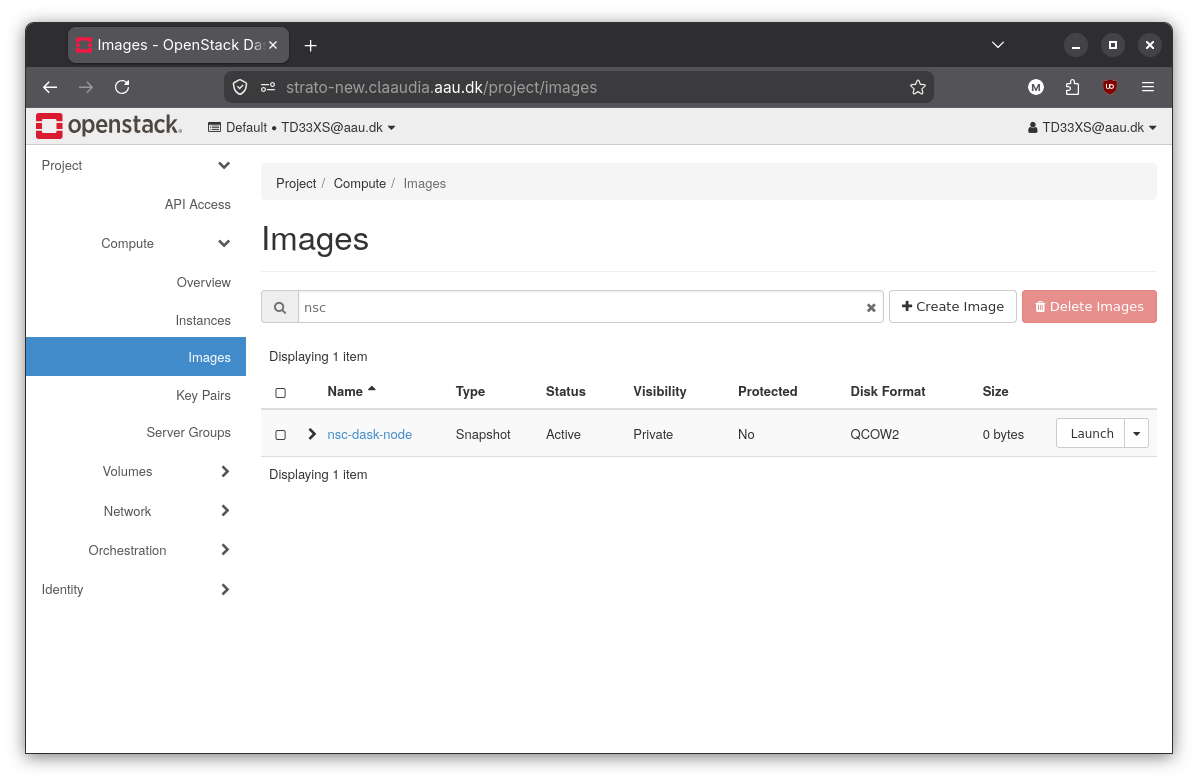
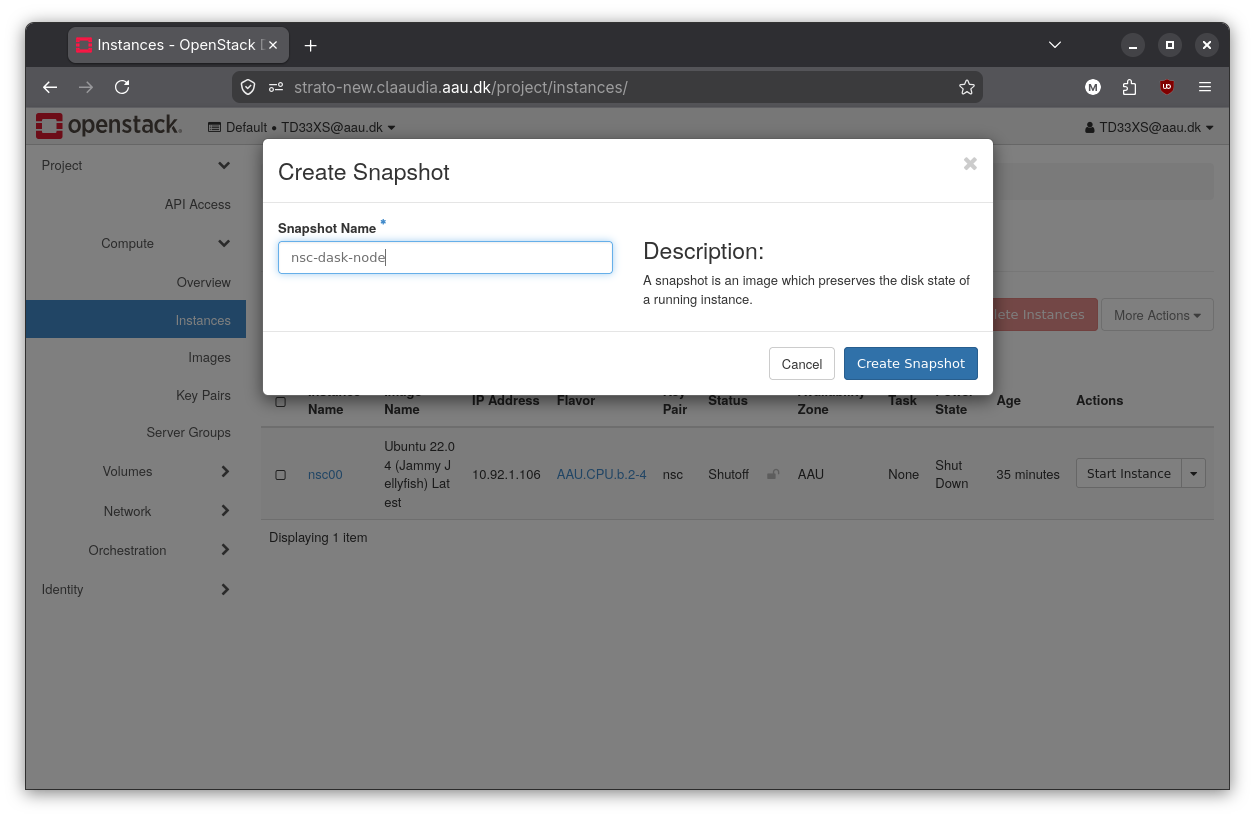

### **2.2 Launch worker VMs from the snapshot**

1. **Go to **Compute → Images**, find your `nsc-dask-node` snapshot.**
2. **Click **Launch** (not the image in the public list — your own snapshot under **Project**).**
3. **Configure each worker VM:**
    - ****Instance Name:** `nsc-worker-1` (repeat for `nsc-worker-2`, etc.)**
    - ****Source:** your snapshot (already selected)**
        - ****Flavor:** `AAU.CPU.b.2-4` (2 vCPUs, 4 GB RAM) — same as head node; launch 2–3 worker VMs for 4–6 total workers. Use `AAU.CPU.d.4-12` if you want 4 workers per VM (2 VMs = 8 workers total)**
    - ****Network:** same as head node**
    - ****Security Group:** same group (ports 22, 8786, 8787 already open)**
    - ****Key Pair:** same key**
    - ****No floating IP needed** on worker VMs**
4. **Launch. Repeat to create 2–3 worker VMs.**

**Note the **internal IP** of each worker from the Instances list — you will need them shortly.**

**Before continuing, **start the head node again**: go to **Compute → Instances**, find the head node (status: Shutoff), click the dropdown → **Start Instance**. Wait until status is **Active**, then SSH back in.**

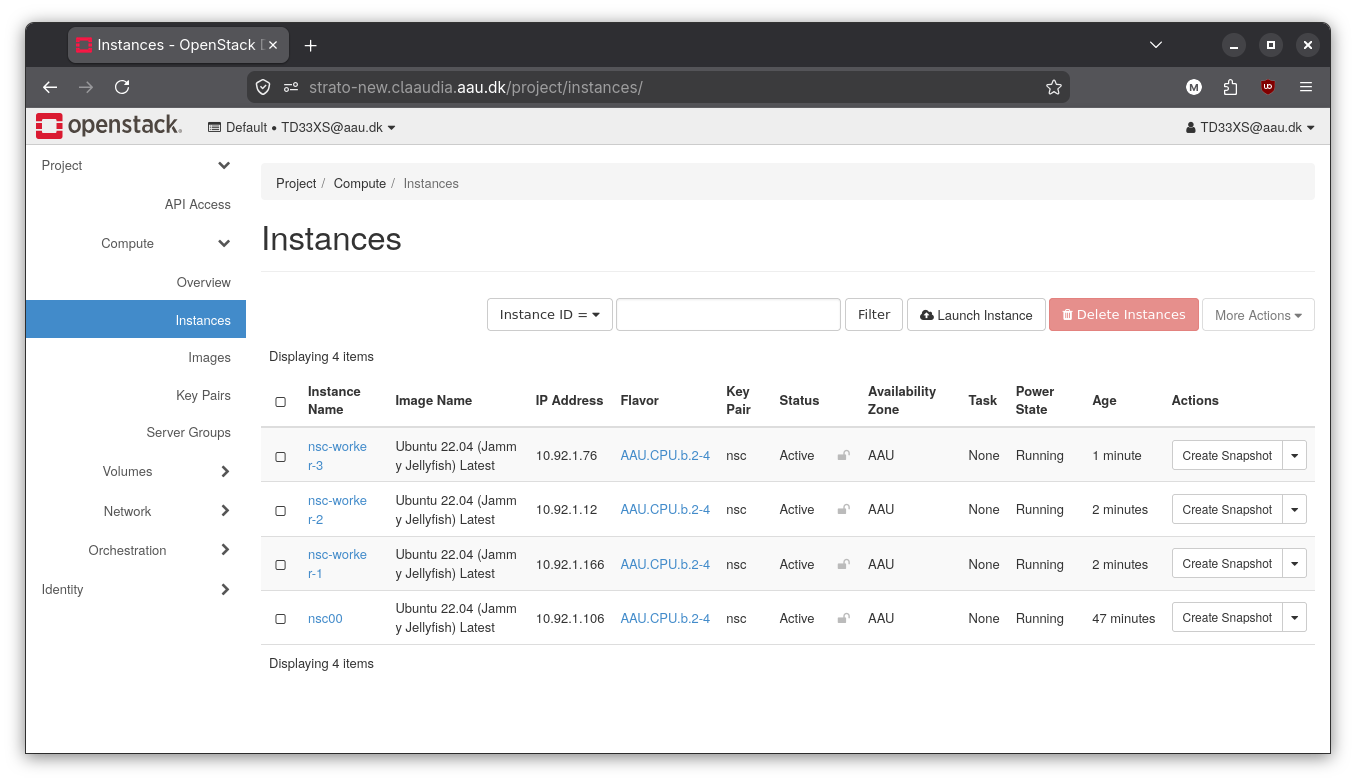

## **Part 3 — Start the Dask Cluster**

### **3.1 Note the head node's IP**
**In the Strato dashboard under **Compute → Instances**, note the IP of your head node (e.g. `10.92.y.x`). This is the **scheduler address** that workers will connect to. Use this same IP in all subsequent steps.**

We can see form the previous exercise that the IPv4 of the head node is 10.92.1.106

### **3.2 Start the scheduler on the head node**

**SSH into the head node. Use tmux so the scheduler keeps running even if your SSH connection drops:**
```sh
tmux new -s dask
conda activate nsc
dask scheduler
```
The scheduler prints several log lines; look for:
```sh
Scheduler at:  tcp://10.92.y.x:8786
dashboard at:  http://10.92.y.x:8787/status
```

****Expected warnings — ignore these:** - `FutureWarning: dask-scheduler is deprecated` — harmless, the command still works. - `To route to workers diagnostics ... install jupyter-server-proxy` — not needed for our use.**

**To detach from tmux without stopping the scheduler: press `Ctrl-B`, then `D`. To reattach later: `tmux attach -t dask`.**

I get the following outout.

```sh
(base) ubuntu@nsc00:~$ conda activate nsc
(nsc) ubuntu@nsc00:~$ dask scheduler
2026-03-27 21:13:39,368 - distributed.scheduler - INFO - -----------------------------------------------
2026-03-27 21:13:42,807 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-03-27 21:13:42,848 - distributed.scheduler - INFO - State start
2026-03-27 21:13:42,850 - distributed.scheduler - INFO - -----------------------------------------------
2026-03-27 21:13:42,851 - distributed.scheduler - INFO -   Scheduler at:    tcp://10.92.1.106:8786
2026-03-27 21:13:42,852 - distributed.scheduler - INFO -   dashboard at:  http://10.92.1.106:8787/status
2026-03-27 21:13:42,852 - distributed.scheduler - INFO - Registering Worker plugin shuffle
```

### **3.3 Start a worker on a VM**

**These steps are the same for every worker VM.**

**Open a terminal on your laptop and SSH into the worker VM (e.g. `10.92.y.x`):**
```sh
ssh -i ~/.ssh/my_ssh_key ubuntu@10.92.y.x
```
**Then on the VM:**
```sh
conda activate nsc
dask worker 10.92.y.x:8786 --nworkers -1 --nthreads 1
```
**Replace `10.92.y.x` with your **head node's IP** (from step 3.1).**

**`--nworkers -1` starts one worker process per available vCPU — so a `AAU.CPU.b.2-4` VM contributes 2 worker processes. `--nthreads 1` gives each process a single thread, which is correct for Numba.**

**Within a few seconds the scheduler window will print:**
```sh
Register worker <Worker ...>
```
**confirming the worker has connected. The dashboard Workers tab also updates immediately.**

for 1 worker joined.

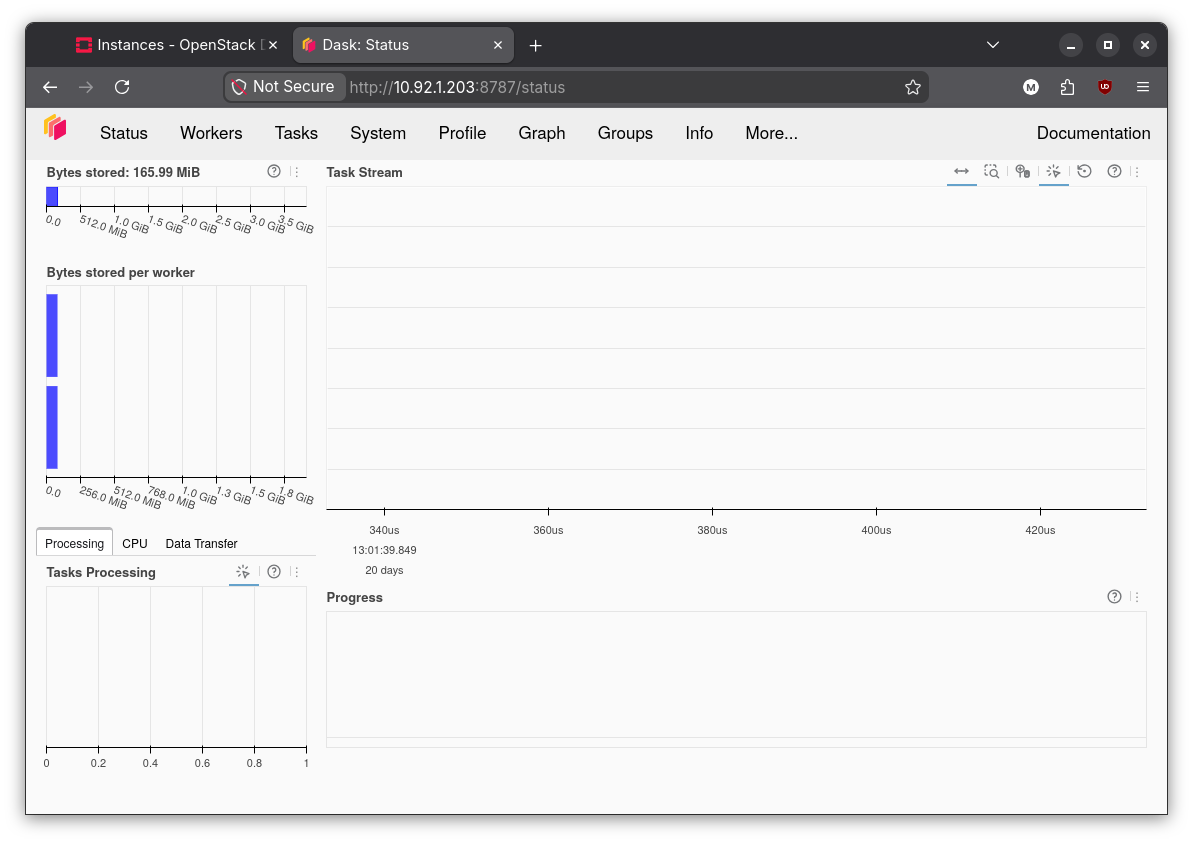

2 workers joined.

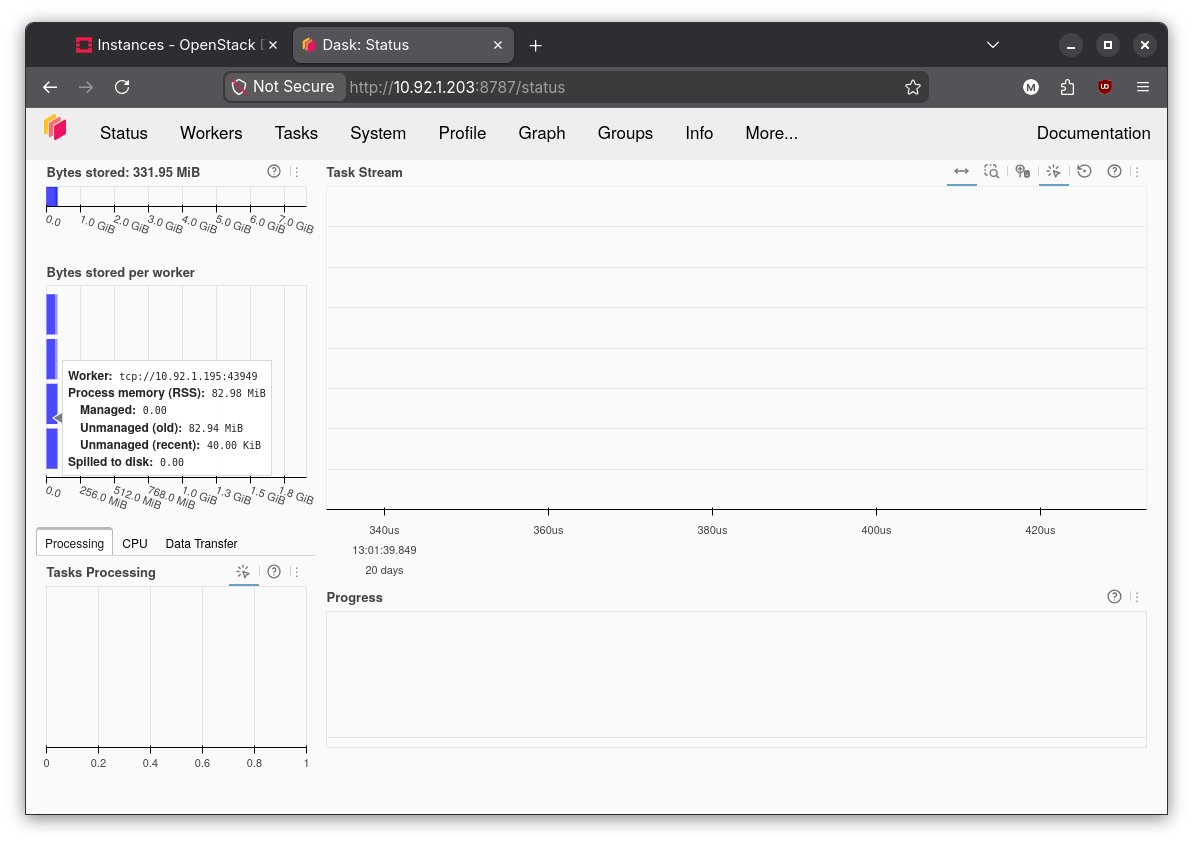

As the last worker number 3.

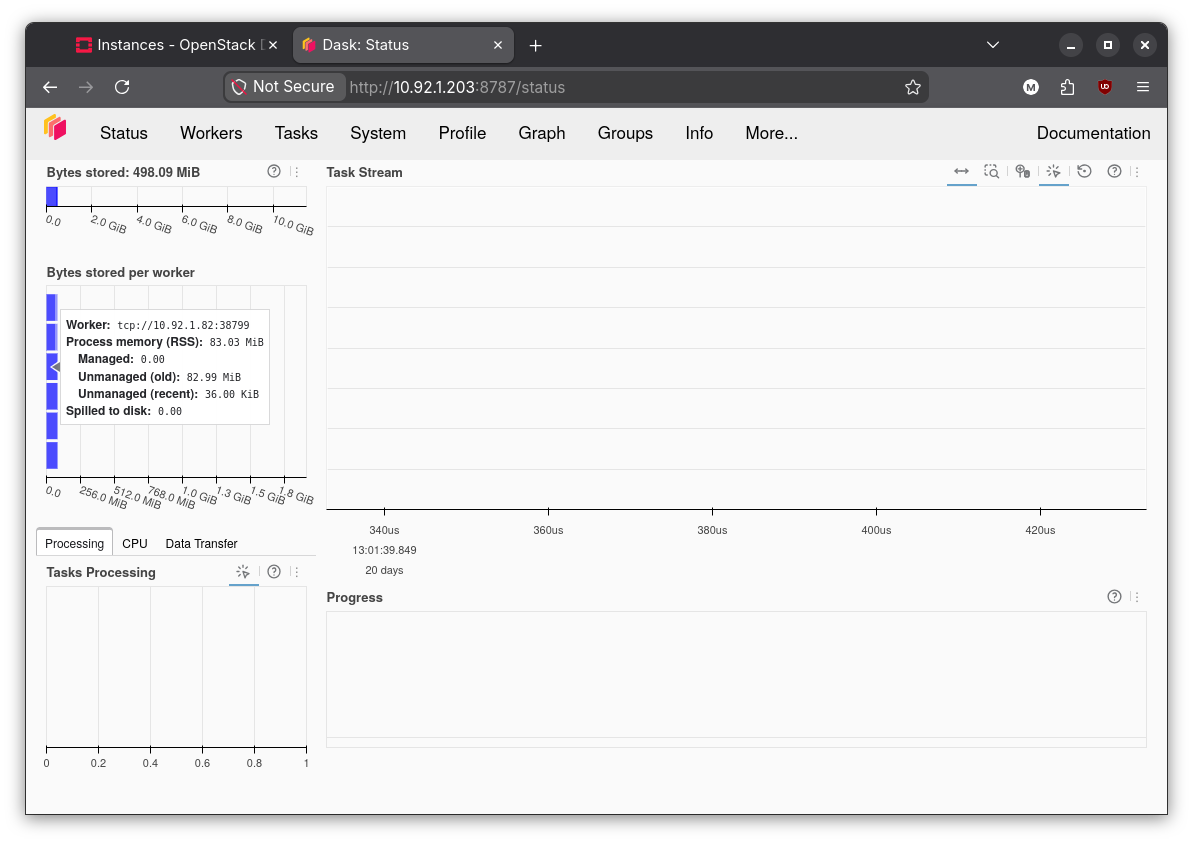

****Experiment 2 (worker scaling):** start with one worker VM connected and run the benchmark, then SSH into a second VM, start its worker, and re-run. Each time you add a VM you increase the worker count by 2 (for the `AAU.CPU.b.2-4` flavor). Record wall time after each addition.**

This is the output form one worker. I run my script on the main node noting what is prints, saving that to a csv file by hand.

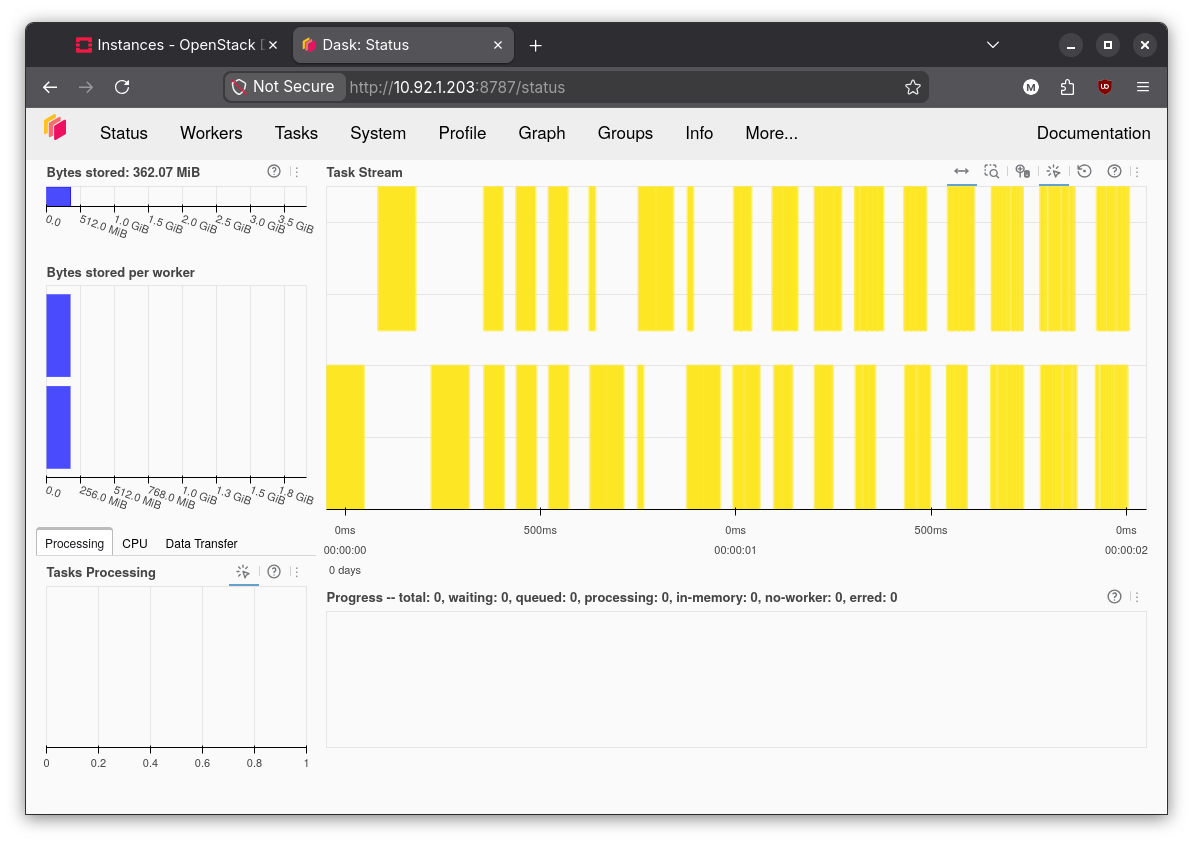

```sh
(nsc) ubuntu@nsc00:~$ python3 mandelbrot_dask.py 
----------
Number of chunks: [1, 2, 4, 8, 16, 32]
Times: [0.1350392379999903, 0.08434975199998007, 0.12069210300001032, 0.10341560099982416, 0.1160798739999791, 0.13164327899994532]
Lifs: [7.0, 3.9970514199723866, 6.150046447982415, 5.126551217644258, 5.8768085909956005, 6.7988164595511]
vs 1x [1.0, 0.6246314274965483, 0.8937558059978019, 0.7658189022055323, 0.8596010738744501, 0.9748520574438875]
Speedups [1.0, 1.6009441023611095, 1.1188738504289608, 1.3057917441317186, 1.1633303289079604, 1.025796675879263]
----------
(nsc) ubuntu@nsc00:~$ python3 mandelbrot_dask.py 
----------
Number of chunks: [1, 2, 4, 8, 16, 32]
Times: [0.1263308899999629, 0.08216724299995803, 0.07804783100004897, 0.07796374299982745, 0.08002007099980801, 0.1071714309998697]
Lifs: [7.0, 4.2033033567630005, 3.942438448748166, 3.937113511974805, 4.067332051556449, 5.786712640108919]
vs 1x [1.0, 0.6504129195953751, 0.6178048060935207, 0.6171391889968506, 0.6334165064445562, 0.8483390800136149]
Speedups [1.0, 1.5374848344373366, 1.6186342193146102, 1.6203800015122733, 1.578740038861825, 1.1787739402314827]
----------
(nsc) ubuntu@nsc00:~$ python3 mandelbrot_dask.py 
----------
Number of chunks: [1, 2, 4, 8, 16, 32]
Times: [0.128776753000011, 0.08500330499987285, 0.07664762799981872, 0.07010760599996502, 0.08269492799990985, 0.09342029899994486]
Lifs: [7.0, 4.2806614870847435, 3.7615816497446346, 3.3552957729853006, 4.13725815092746, 4.803550521261356]
vs 1x [1.0, 0.6600826858855929, 0.5951977062180793, 0.5444119716231626, 0.6421572688659325, 0.7254438151576695]
Speedups [1.0, 1.514961718255586, 1.6801140017055136, 1.8368442505378841, 1.5572509235409382, 1.3784665043738193]
----------
```

with number of workers 1, 2, 3 respectively.

I have converted it to a csv file, so that it is easier to work with.

In [3]:
from IPython.display import Markdown, display
import pandas as pd

df_display = pd.read_csv("l07_part3.csv")
df_display["time"] = df_display["time"].map("{:>.3f}s".format)
df_display["vs1x"] = df_display["vs1x"].map("{:>.2f}x".format)
df_display["speedup"] = df_display["speedup"].map("{:>.2f}x".format)
df_display["lif"] = df_display["lif"].map("{:>.2f}".format)

display(Markdown(df_display.to_markdown(index=False)))

|   workers |   chunks | time   |   lif | vs1x   | speedup   |
|----------:|---------:|:-------|------:|:-------|:----------|
|         1 |        1 | 0.135s |  7    | 1.00x  | 1.00x     |
|         1 |        2 | 0.084s |  4    | 0.62x  | 1.60x     |
|         1 |        4 | 0.121s |  6.15 | 0.89x  | 1.12x     |
|         1 |        8 | 0.103s |  5.13 | 0.77x  | 1.31x     |
|         1 |       16 | 0.116s |  5.88 | 0.86x  | 1.16x     |
|         1 |       32 | 0.132s |  6.8  | 0.97x  | 1.03x     |
|         2 |        1 | 0.126s |  7    | 1.00x  | 1.00x     |
|         2 |        2 | 0.082s |  4.2  | 0.65x  | 1.54x     |
|         2 |        4 | 0.078s |  3.94 | 0.62x  | 1.62x     |
|         2 |        8 | 0.078s |  3.94 | 0.62x  | 1.62x     |
|         2 |       16 | 0.080s |  4.07 | 0.63x  | 1.58x     |
|         2 |       32 | 0.107s |  5.79 | 0.85x  | 1.18x     |
|         3 |        1 | 0.129s |  7    | 1.00x  | 1.00x     |
|         3 |        2 | 0.085s |  4.28 | 0.66x  | 1.51x     |
|         3 |        4 | 0.077s |  3.76 | 0.60x  | 1.68x     |
|         3 |        8 | 0.070s |  3.36 | 0.54x  | 1.84x     |
|         3 |       16 | 0.083s |  4.14 | 0.64x  | 1.56x     |
|         3 |       32 | 0.093s |  4.8  | 0.73x  | 1.38x     |

## **Part 4 — Adapt Your Code and Run on the Head Node**

### **4.1 SSH into the head node**
```sh
ssh -i ~/.ssh/my_ssh_key ubuntu@10.92.y.x
conda activate nsc
```
**If you prefer to work in a Jupyter notebook instead of running a script directly, see the Appendix: [Jupyter Notebook at the end of this guide](https://www.moodle.aau.dk/mod/page/view.php?id=2076079#appendix-jupyter-notebook).**


Plain ssh is fine by me.

This is the output I get

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ ssh -i nsc ubuntu@10.92.1.203
Welcome to Ubuntu 22.04.5 LTS (GNU/Linux 5.15.0-173-generic x86_64)

 * Documentation:  https://help.ubuntu.com
 * Management:     https://landscape.canonical.com
 * Support:        https://ubuntu.com/pro

 System information as of Mon Mar 30 20:32:35 UTC 2026

  System load:  0.01               Processes:             104
  Usage of /:   11.7% of 48.27GB   Users logged in:       1
  Memory usage: 8%                 IPv4 address for ens3: 10.92.1.203
  Swap usage:   0%


Expanded Security Maintenance for Applications is not enabled.

0 updates can be applied immediately.

Enable ESM Apps to receive additional future security updates.
See https://ubuntu.com/esm or run: sudo pro status


The list of available updates is more than a week old.
To check for new updates run: sudo apt update
New release '24.04.4 LTS' available.
Run 'do-release-upgrade' to upgrade to it.


Last login: Mon Mar 30 19:50:39 2026 from 172.30.54.43
(base) ubuntu@nsc00:~$ 
```

### **4.2 Run your script**
```sh
python mandelbrot_dask.py
```
**The output should include a line like:**
```sh
<Client: 'tcp://10.92.y.x:8786' processes=6 threads=6, memory=11.46 GiB>
```

```sh
(base) ubuntu@nsc00:~$ conda activate nsc
(nsc) ubuntu@nsc00:~$ python mandelbrot_dask.py 
```

I do not get the client print since I do not print it in my code.

### **4.3 Check the dashboard**

**From your laptop browser (VPN required if off-campus):**

http://10.92.y.x:8787

**You should see all workers listed under the **Workers** tab and tasks executing in real time.**

I do see them!

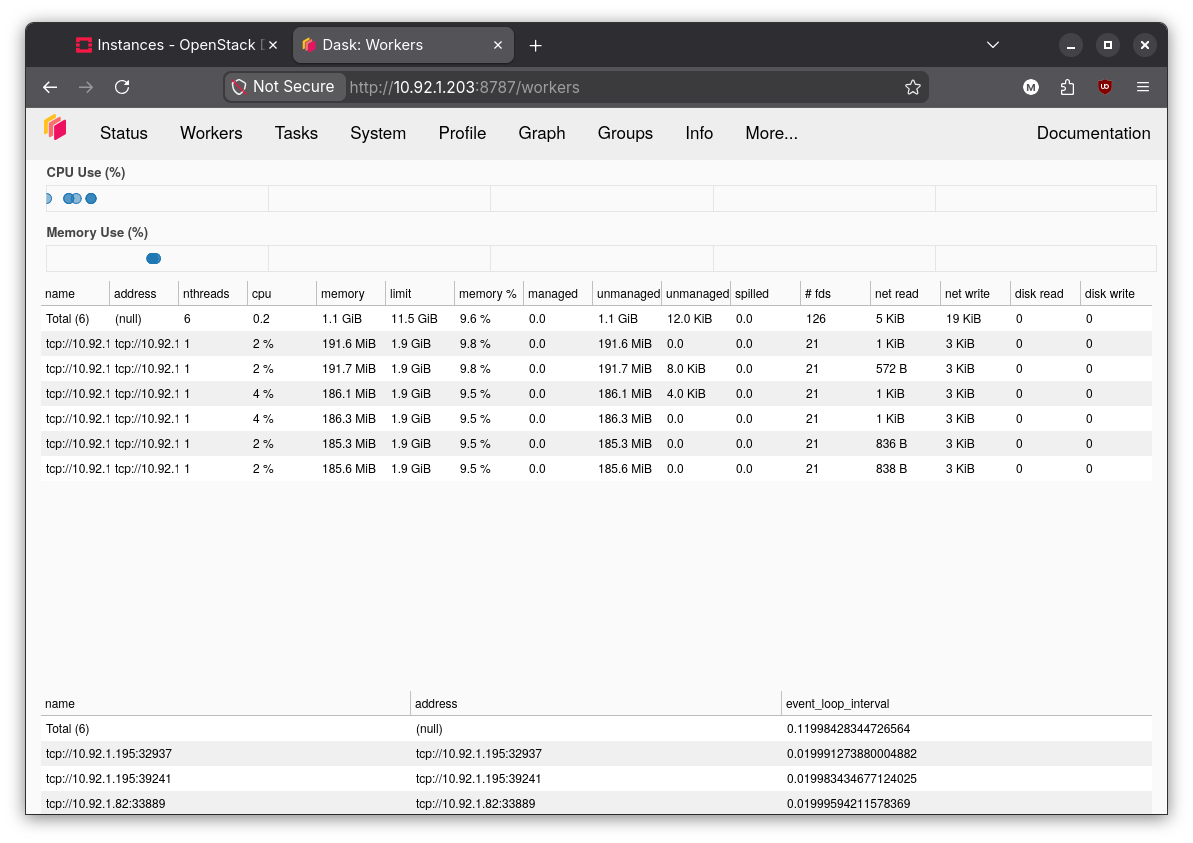

### **4.4 Smoke test**

**Before benchmarking, verify all workers have the same package versions:**
```python
versions = client.run(lambda: __import__('dask').__version__)
print(versions)   # all values must be identical
```
**If any worker shows a different version, delete the mismatched VM, re-launch from the snapshot, and reconnect.**

In each VM in run

```python
from dask.distributed import Client
client = Client()
versions = client.run(lambda: __import__('dask').__version__)
print(versions)
```

```sh
(nsc) ubuntu@nsc00:~$ python
Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> from dask.distributed import Client
>>> client = Client()
/home/ubuntu/miniconda3/envs/nsc/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40925 instead
  warnings.warn(
>>> versions = client.run(lambda: __import__('dask').__version__)
>>> print(versions)
{'tcp://127.0.0.1:35949': '2026.3.0', 'tcp://127.0.0.1:42887': '2026.3.0'}
```

```sh
(nsc) ubuntu@nsc-worker-1:~$ python
Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> from dask.distributed import Client
>>> client = Client()
>>> versions = client.run(lambda: __import__('dask').__version__)
>>> print(versions)
{'tcp://127.0.0.1:33187': '2026.3.0', 'tcp://127.0.0.1:39931': '2026.3.0'}
```

```sh
(nsc) ubuntu@nsc-worker-2:~$ python
Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> from dask.distributed import Client
>>> client = Client()
>>> versions = client.run(lambda: __import__('dask').__version__)
>>> print(versions)
{'tcp://127.0.0.1:38511': '2026.3.0', 'tcp://127.0.0.1:41779': '2026.3.0'}
```

```sh
(nsc) ubuntu@nsc-worker-3:~$ python
Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0] on linux
Type "help", "copyright", "credits" or "license" for more information.
>>> from dask.distributed import Client
>>> client = Client()
>>> versions = client.run(lambda: __import__('dask').__version__)
>>> print(versions)
{'tcp://127.0.0.1:38671': '2026.3.0', 'tcp://127.0.0.1:42203': '2026.3.0'}
```

They *all* have the same dask version.

## **Part 5 — Benchmark**

**Use **N=4096** or **N=8192** for meaningful speedup — at 1024×1024 scheduling overhead dominates and speedup will be low.**

****Head node RAM:** `dask.compute()` assembles the full result on the head node. A 4096×4096 float64 grid is ~128 MB — fine on a small VM. At 8192×8192 it is ~512 MB, and at 16384×16384 it is ~2 GB. If you want to go beyond 8192, resize the head node to a larger flavor (e.g. `AAU.CPU.b.4-8`) before running, otherwise the process may be killed by the OS. Workers do not need resizing — only the head node collects the result.**

**Record your results in the performance tracker — include a Numba single-core run at the same resolution so speedup can be computed.**

I used $N=4096$. I did the same as in part 3, saving the results to a csv file. Regarding the Numba case, I copied the code from lecture 4.

In [5]:
# From lecture 4

# From slide 45 (The updated once)

# mandelbrot_parallel.py (Tasks 1-3 are one continuous script)
import numpy as np
from numba import njit

@njit
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = z_imag = 0.0
    for i in range(max_iter):
        zr2 = z_real*z_real
        zi2 = z_imag*z_imag
        if zr2 + zi2 > 4.0: return i
        z_imag = 2.0*z_real*z_imag + c_imag
        z_real = zr2 - zi2 + c_real
    return max_iter

@njit
def mandelbrot_chunk(row_start, row_end, N,
                     x_min, x_max, y_min, y_max, max_iter):
    out = np.empty((row_end - row_start, N), dtype=np.int32)
    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N
    for r in range(row_end - row_start):
        c_imag = y_min + (r + row_start) * dy
        for col in range(N):
            out[r, col] = mandelbrot_pixel(x_min + col*dx, c_imag, max_iter)
    return out

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter=100):
    return mandelbrot_chunk(0, N, N, x_min, x_max, y_min, y_max, max_iter)

In [6]:
import statistics
import time

times = []
for _ in range(3):
    t0 = time.perf_counter()
    mandelbrot_serial(4096, -2.5, 1.0, -1.25, 1.25)
    times.append(time.perf_counter() - t0)
print(statistics.median(times))

0.71728592099862


In [9]:
from IPython.display import Markdown, display
import pandas as pd


df = pd.read_csv("l07_part5.csv")

# Compute speedups
t0 = 0.71728592099862 
df["speedup"] = t0 / df["time"]

# Display as table
df["time"] = df["time"].map("{:>.3f}s".format)
df["speedup"] = df["speedup"].map("{:>.2f}x".format)
display(Markdown(df[["workers", "chunks", "time", "speedup"]].to_markdown(index=False)))

|   workers |   chunks | time   | speedup   |
|----------:|---------:|:-------|:----------|
|         1 |        1 | 1.646s | 0.44x     |
|         1 |        2 | 0.907s | 0.79x     |
|         1 |        4 | 0.918s | 0.78x     |
|         1 |        8 | 1.011s | 0.71x     |
|         1 |       16 | 1.011s | 0.71x     |
|         1 |       32 | 0.984s | 0.73x     |
|         2 |        1 | 1.527s | 0.47x     |
|         2 |        2 | 0.933s | 0.77x     |
|         2 |        4 | 0.858s | 0.84x     |
|         2 |        8 | 0.758s | 0.95x     |
|         2 |       16 | 0.646s | 1.11x     |
|         2 |       32 | 0.598s | 1.20x     |
|         3 |        1 | 1.700s | 0.42x     |
|         3 |        2 | 0.951s | 0.75x     |
|         3 |        4 | 0.841s | 0.85x     |
|         3 |        8 | 0.873s | 0.82x     |
|         3 |       16 | 0.540s | 1.33x     |
|         3 |       32 | 0.559s | 1.28x     |

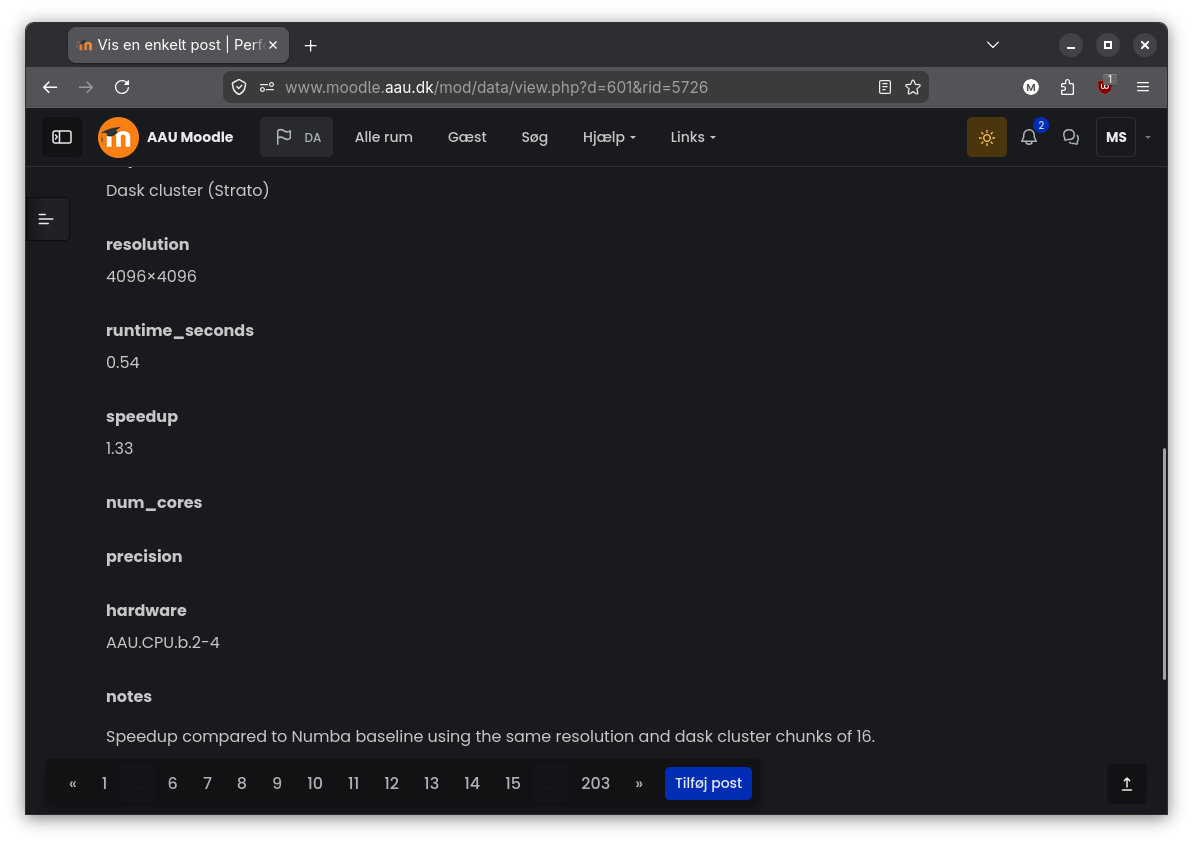

## **Part 6 — Clean Up When Done**

**Running VMs consume your quota even when idle.**

1. ****Worker VMs:** Delete them — you can always re-launch from the snapshot in minutes. In **Compute → Instances**, select each worker, click **Delete Instances**.**
2. ****Head node:** You have two options:**
    - ****Shelve (recommended):** frees the vCPU/RAM quota but keeps the disk. Resume later with Unshelve — faster than re-launching. Click the dropdown → **Shelve Instance**.**
    - ****Delete:** removes everything. Only do this if you are certain you no longer need it. Your snapshot still exists and you can re-launch from it.**
3. ****Snapshot:** Keep it. Snapshots use storage quota (not compute quota) and let you rebuild the cluster in minutes next time.**


I have chosen to just delete the instances but keep their virtual disks.

## **Troubleshooting**

****Worker won't connect to scheduler****
- **Check that port 8786 is open in the security group (Part 1.1).**
- **Confirm you are using the head node's IP from the Instances list (e.g. `10.92.y.x`).**
- **Check the scheduler is still running: `tmux attach -t dask` on the head node.**

****Dashboard not loading in browser****
- **Confirm port 8787 is open in the security group.**
- **Confirm VPN is connected.**
- **Try http://10.92.y.x:8787 (not https).**

****SSH connection drops / scheduler stops****
- **Always use `tmux` for the scheduler (Part 3.2). If you forgot and it stopped, just re-run `dask scheduler` and reconnect the workers.**

****VPN not working at AAU****
- **Use your laptop as a mobile hotspot (share from your phone).**
- **Connect both your laptop and any physical co-worker laptops to that hotspot.**
- **Use internal IPs as normal — devices on the same hotspot subnet can reach each other directly.**
- **This also works if you want to form a temporary cluster using classmates' laptops as additional workers: each person runs `dask worker YOUR_IP:8786` on their own machine.**

****Version mismatch between workers****
- **Always launch workers from the snapshot, not from the base Ubuntu image.**
- **Run the smoke test (Part 4.5) to catch mismatches before benchmarking.**

## **Appendix: Jupyter Notebook**

**If you prefer working in a notebook rather than running a script, you can run Jupyter on the head node and tunnel it to your laptop browser.**

****On the head node:****
```sh
conda activate nsc
jupyter notebook --no-browser --port=8888
```
****On your laptop (in a separate terminal):****
```sh
ssh -i ~/.ssh/my_ssh_key -L 8888:localhost:8888 ubuntu@10.92.y.x -N
```
**Then open http://localhost:8888 in your browser.**

**The three code changes in Part 4.2 apply equally to a notebook — replace the `LocalCluster` cell with `client = Client("tcp://10.92.y.x:8786")` and remove any `cluster.close()` call.**